# LevitationSim6x6 — rigid-body thermophoretic levitation with full 6×6 linear response

This notebook is a from-scratch Python re-implementation of the interactive simulator `Theory/sim_symmetric.jsx`. It keeps everything that simulator does:

* the 13-variable quaternion ODE,
* the harmonic trap,
* fixed-step RK4,
* a 3-D animation with play/scrub and elevation/azimuth controls,
* the time-series panels.

It also fixes the modelling problems listed in the caveats section of `Theory/sim_symmetric_physics.tex`. The four separately-symmetrised $3\times3$ tensors are replaced by a **6×6 generalised-force formalism**.

Each section explains the physics before the code that implements it. The later sections compute the response tensors for a small library of physical particles (spheres, ellipsoids, and ellipsoids with a linear density gradient) and simulate them in SI units.

> **How to use.** Run the notebook top to bottom (*Run ▸ Run All Cells*). Lines starting with **PASS/FAIL** are self-tests. Their expected values come from three sources: the output of the original JavaScript simulator, an independent Python reference script written while developing this notebook, and closed-form limits. Section 13 summarises all the tests. Everything is in SI units. The interactive viewer and explorer need `ipywidgets` (`pip install ipywidgets`); every other cell runs with only numpy, scipy and matplotlib.

## 0. What changed relative to `sim_symmetric.jsx`

| Issue in `sim_symmetric.jsx` | Treatment here |
|---|---|
| Four separate symmetric $3\times3$ tensors $\Xi,\Gamma,\Lambda,C_r$ (24 numbers) | One symmetric positive-definite $6\times6$ resistance matrix $\mathcal R$ (21 numbers, including the translation–rotation coupling block $B$), plus one general $6\times3$ thermophoretic matrix $\mathcal T=(\Gamma;\Lambda)$ (18 numbers) |
| $\Gamma$ forced symmetric | $\Gamma$ is a general $3\times3$ matrix; Onsager reciprocity does not constrain this coefficient on its own |
| $\Lambda$ forced symmetric | $\Lambda$ is a general pseudotensor. Its antisymmetric part produces the alignment torque $\propto\hat{\mathbf n}\times\nabla\ln T$ of polar (cone-like, Janus) particles |
| No translation–rotation coupling in drag | Coupling block $B$ of $\mathcal R$ included (chiral bodies, and any off-centre reference point) |
| Diagonal inertia only | Full symmetric inertia tensor about the centre of mass |
| Force centre = centre of mass | Separate thermophoretic/hydrodynamic centre H with offset $\mathbf r_H$. Tensors given at H are shifted to the COM exactly, and $\nabla\ln T$ is evaluated at H |
| Levitation offset used $\Gamma_{22}$ (a $y$ component) | Offset balances gravity exactly for any $\Gamma$ and reference orientation: $g_0=Mg\,[(R_0\Gamma R_0^{\mathsf T})^{-1}]_{zz}$. The old behaviour is kept as `g0_mode="LegacyJS"` |
| Positivity of dissipation not checked | `validate_particle` checks symmetry and positive-definiteness of $\mathcal R$ and $I$ |
| Fixed-step RK4 only | RK4 (exact port) plus an adaptive, stiffness-aware integrator. Diagnostics for the energy budget, quaternion drift, linear stability and RK4 stability |
| Arbitrary units | SI throughout, plus a physical particle library (air at a given $T$, $p$) |

## 1. Setup

In [1]:
from dataclasses import dataclass, field, replace
from pathlib import Path
from typing import Callable, Optional

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, colors
from scipy.integrate import solve_ivp, quad
from scipy.special import elliprf, elliprd
from IPython.display import display, HTML, SVG, Markdown

np.set_printoptions(precision=5, linewidth=130)
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3, "font.size": 9,
                     "axes.formatter.useoffset": False})
NB_DIR = Path.cwd()
FIG_DIR = NB_DIR / "figures"

TEST_RESULTS = {}

def _report(label, ok, got, expected, err, kind):
    TEST_RESULTS[label] = bool(ok)
    tag = "PASS" if ok else "FAIL"
    print(f"{tag}  {label}\n      got {np.array2string(np.asarray(got), precision=8)}   "
          f"expected {np.array2string(np.asarray(expected), precision=8)}   {kind} err {err:.2e}")

def check_close(label, got, expected, rtol=1e-3):
    """Relative check on the 2-norm (works for scalars, vectors, complex numbers)."""
    g, e = np.atleast_1d(np.asarray(got, dtype=complex)), np.atleast_1d(np.asarray(expected, dtype=complex))
    err = np.linalg.norm(g - e) / max(np.linalg.norm(e), 1e-300)
    _report(label, err <= rtol, got, expected, err, "rel.")

def check_abs(label, got, expected, atol):
    err = np.linalg.norm(np.atleast_1d(np.asarray(got, dtype=complex) - np.asarray(expected, dtype=complex)))
    _report(label, err <= atol, got, expected, err, "abs.")

## 2. Kinematics: frames, quaternions, rotation matrices

The **lab frame** has $\hat{\mathbf e}_z$ pointing up, against gravity. The **body frame** is attached to the particle, and every response tensor is constant in it. The rotation matrix $R$ maps body components to lab components, $\mathbf a_{\rm lab}=R\,\mathbf a_b$. It is parametrised by a unit quaternion $q=(q_0,\mathbf q)$:

$$R(q)=(q_0^2-|\mathbf q|^2)\,\mathbb I+2\,\mathbf q\mathbf q^{\mathsf T}+2q_0[\mathbf q]_\times ,$$

where $[\mathbf a]_\times\mathbf b=\mathbf a\times\mathbf b$. The orientation evolves with the **body-frame** angular velocity $\boldsymbol\omega_b$, multiplied on the right:

$$\dot q=\tfrac12\,q\otimes(0,\boldsymbol\omega_b),\qquad
\dot q_0=-\tfrac12\,\mathbf q\cdot\boldsymbol\omega_b,\qquad
\dot{\mathbf q}=\tfrac12\bigl(q_0\boldsymbol\omega_b+\mathbf q\times\boldsymbol\omega_b\bigr),$$

or equivalently $\dot R=R\,[\boldsymbol\omega_b]_\times$. The *tilt* shown by the original simulator is the angle between the body axis $\hat{\mathbf e}_3$ and the vertical, $\theta=\arccos R_{33}$.

The functions below are exact ports of the JavaScript helpers. They avoid `np.linalg.norm` and use only polynomial and `sqrt` operations, so they also accept complex arguments. The complex-step Jacobian in Section 7.2 relies on this.

In [2]:
def quat_to_R(q):
    q0, q1, q2, q3 = q
    return np.array([[1 - 2*(q2*q2 + q3*q3), 2*(q1*q2 - q0*q3),     2*(q1*q3 + q0*q2)],
                     [2*(q1*q2 + q0*q3),     1 - 2*(q1*q1 + q3*q3), 2*(q2*q3 - q0*q1)],
                     [2*(q1*q3 - q0*q2),     2*(q2*q3 + q0*q1),     1 - 2*(q1*q1 + q2*q2)]])

def q_dot(q, w):
    q0, q1, q2, q3 = q
    return 0.5*np.array([-q1*w[0] - q2*w[1] - q3*w[2],
                          q0*w[0] - q3*w[1] + q2*w[2],
                          q3*w[0] + q0*w[1] - q1*w[2],
                         -q2*w[0] + q1*w[1] + q0*w[2]])

def q_mul(a, b):
    a0, av, b0, bv = a[0], np.asarray(a[1:]), b[0], np.asarray(b[1:])
    return np.concatenate([[a0*b0 - av @ bv], a0*bv + b0*av + np.cross(av, bv)])

def normalize_q(q):
    q = np.asarray(q)
    return q / np.sqrt(q @ q)

def axis_angle_q(axis, deg):
    k = np.asarray(axis, float) / np.linalg.norm(axis)
    h = np.deg2rad(deg) / 2
    return np.concatenate([[np.cos(h)], np.sin(h)*k])

def skew(a):
    return np.array([[0, -a[2], a[1]], [a[2], 0, -a[0]], [-a[1], a[0], 0]])

def tilt_deg(q):
    return np.degrees(np.arccos(np.clip(quat_to_R(normalize_q(q))[2, 2], -1, 1)))

**Self-test.** $R$ should be orthogonal with unit determinant. A finite-difference derivative of $R$ along $\dot q$ should equal $R[\boldsymbol\omega_b]_\times$.

In [3]:
rng = np.random.default_rng(1)
q, w, h = normalize_q(rng.uniform(-1, 1, 4)), rng.uniform(-1, 1, 3), 1e-6
R = quat_to_R(q)
dR = (quat_to_R(q + h*q_dot(q, w)) - quat_to_R(q - h*q_dot(q, w))) / (2*h)
check_abs("R orthogonal", np.linalg.norm(R.T @ R - np.eye(3)), 0, 1e-12)
check_abs("det R = 1", np.linalg.det(R), 1, 1e-12)
check_abs("dR/dt = R [w]x  (body-frame angular velocity)", np.linalg.norm(dR - R @ skew(w)), 0, 1e-8)

PASS  R orthogonal
      got 9.44474993e-16   expected 0   abs. err 9.44e-16
PASS  det R = 1
      got 1.   expected 1   abs. err 6.66e-16
PASS  dR/dt = R [w]x  (body-frame angular velocity)
      got 2.45303766e-10   expected 0   abs. err 2.45e-10


## 3. Generalised forces: the 6×6 formalism

### 3.1 Twists, wrenches and power

Collect the rigid-body velocities about a reference point O into a body-frame **twist** $\mathbf U=(\mathbf v_b,\boldsymbol\omega_b)\in\mathbb R^6$, and the force and torque about O into a **wrench** $\mathbf F=(\mathbf f_b,\boldsymbol\tau_b)$. The mechanical power is $\mathbf U\cdot\mathbf F$. The gas couples to the body through two linear-response operators:

$$\mathbf F_{\rm drag}=-\mathcal R\,\mathbf U,\qquad \mathbf F_{\rm T}=-\mathcal T\,\mathbf G_b,\qquad \mathbf G_b=R^{\mathsf T}\nabla\ln T,$$

$$\mathcal R=\begin{pmatrix}K & B\\ B^{\mathsf T} & \Omega\end{pmatrix}\in\mathbb R^{6\times6},\qquad
\mathcal T=\begin{pmatrix}\Gamma\\ \Lambda\end{pmatrix}\in\mathbb R^{6\times3}.$$

* $K$ is the translational resistance and $\Omega$ the rotational resistance. $B$ is the translation–rotation coupling: rotation produces the force $-B\boldsymbol\omega_b$, and translation produces the torque $-B^{\mathsf T}\mathbf v_b$.
* $\Gamma$ is the thermophoretic force per unit $\nabla\ln T$ (units N·m). $\Lambda$ is the thermophoretic torque per unit $\nabla\ln T$ (N·m²).

### 3.2 Which symmetries are real

**$\mathcal R$ is symmetric and positive definite.** At low Reynolds number the Lorentz reciprocal theorem makes the grand resistance matrix symmetric, $\mathcal R=\mathcal R^{\mathsf T}$. For rarefied gases, Onsager–Casimir reciprocity plays the same role, since all velocities are odd under time reversal. The second law requires the dissipated power $\mathbf U\cdot\mathcal R\mathbf U\ge 0$. Note that the *block* $B$ is **not** symmetric in general. The JavaScript simulator had no $B$ at all.

**$\mathcal T$ has no symmetry of its own.** Onsager reciprocity relates $\mathcal T$ to the *reverse* cross-effect, the heat flux induced by moving the body, not to itself. So $\Gamma$ is a general $3\times3$ matrix. $\Lambda$ is a general pseudotensor, because it maps a polar vector to an axial one. What constrains $\mathcal T$ is the particle's point-group symmetry:

* **Centrosymmetric bodies** (sphere, ellipsoid, cylinder), about their centre: $\Lambda=0$, because inversion flips the sign of a pseudotensor.
* **Polar, achiral bodies** with symmetry $C_{\infty v}$ about the axis $\hat{\mathbf n}$ (a cone, or a Janus sphere): $\Lambda=\lambda_a[\hat{\mathbf n}]_\times$ is purely **antisymmetric**. It gives the torque $\boldsymbol\tau=-\lambda_a\,\hat{\mathbf n}\times\mathbf G_b$, which aligns $\hat{\mathbf n}$ with the gradient. The old symmetric constraint removed exactly this effect (demo in Section 9.3).
* **Chiral bodies** ($D_\infty$, helix-like): a symmetric $\Lambda={\rm diag}(\lambda_1,\lambda_1,\lambda_3)$ makes the body spin in a gradient. Chirality also allows $B\neq0$ (Section 9.4).

### 3.3 Changing the reference point

The tensors are usually known about a geometric centre H, such as the centre of an ellipsoid. Newton–Euler is simplest about the centre of mass. Let $\mathbf r_H$ be the body-frame vector from the COM to H. Then $\mathbf v_H=\mathbf v+\boldsymbol\omega\times\mathbf r_H$ and $\boldsymbol\tau_{\rm COM}=\boldsymbol\tau_H+\mathbf r_H\times\mathbf f$. In $6\times6$ form this is a congruence:

$$\mathbf U_H=\mathcal P\,\mathbf U_{\rm COM},\quad \mathbf F_{\rm COM}=\mathcal P^{\mathsf T}\mathbf F_H,\quad
\mathcal P=\begin{pmatrix}\mathbb I & -[\mathbf r_H]_\times\\ 0 & \mathbb I\end{pmatrix}
\quad\Longrightarrow\quad
\mathcal R_{\rm COM}=\mathcal P^{\mathsf T}\mathcal R_H\mathcal P,\qquad \mathcal T_{\rm COM}=\mathcal P^{\mathsf T}\mathcal T_H .$$

The congruence preserves symmetry and positive-definiteness. It generates the coupling block $B_{\rm COM}=B_H-K[\mathbf r_H]_\times$ and the torque term $\Lambda_{\rm COM}=\Lambda_H+[\mathbf r_H]_\times\Gamma$. In words, the thermophoretic force acts at H, so it exerts a torque about the COM, and this is what rights the bottom-heavy particle of Section 10.4. The field is sampled at the point where it acts: $\mathbf G_b=R^{\mathsf T}\nabla\ln T(\mathbf x_{\rm COM}+R\,\mathbf r_H)$.

In [4]:
I3 = np.eye(3)
Z3 = np.zeros((3, 3))

def iso3(s):           return s * np.eye(3)
def diag3(a, b, c):    return np.diag([a, b, c]).astype(float)
def from_packed(t):    # the JS storage format [t11, t12, t13, t22, t23, t33]
    t11, t12, t13, t22, t23, t33 = t
    return np.array([[t11, t12, t13], [t12, t22, t23], [t13, t23, t33]], float)
def symmetrize(m):     return (m + m.T) / 2
def resistance_from_blocks(K, B, Om):  return np.block([[K, B], [B.T, Om]]).astype(float)
def thermo_from_blocks(Gam, Lam):      return np.vstack([Gam, Lam]).astype(float)
def shift_matrix(r):                   return np.block([[I3, -skew(r)], [Z3, I3]])

### 3.4 Particle objects

A `Particle` holds:

* `mass` $M$, and `inertia`, the full symmetric inertia tensor about the COM in body axes;
* `res`, the $6\times6$ matrix $\mathcal R_H$ about H, `thermo`, the $6\times3$ matrix $\mathcal T_H$ about H, and `rH`, the body-frame vector from the COM to H;
* `shape` (used only for drawing) and `meta` (free-form information such as the Knudsen number or thermophoretic velocity).

`validate_particle` checks the physical constraints. Those include the triangle inequality $I_1\le I_2+I_3$ on the principal moments, which every real mass distribution satisfies.

In [5]:
@dataclass
class Particle:
    name: str
    mass: float
    inertia: np.ndarray                      # 3x3 about COM, body frame
    res: np.ndarray                          # 6x6 resistance about H
    thermo: np.ndarray                       # 6x3 thermophoretic matrix about H
    rH: np.ndarray = field(default_factory=lambda: np.zeros(3))   # COM -> H, body frame
    shape: dict = field(default_factory=lambda: {"type": "cylinder", "half_length": 0.10, "radius": 0.034})
    meta: dict = field(default_factory=dict)

    def __post_init__(self):
        self.inertia = np.asarray(self.inertia, float)
        self.res = np.asarray(self.res, float)
        self.thermo = np.asarray(self.thermo, float)
        self.rH = np.asarray(self.rH, float)

    def at_com(self):
        """Return (R_COM, T_COM): the tensors referred to the centre of mass."""
        P = shift_matrix(self.rH)
        return P.T @ self.res @ P, P.T @ self.thermo

    @property
    def Gamma(self):  return self.thermo[:3]
    @property
    def length_scale(self):
        if "length_scale" in self.meta: return self.meta["length_scale"]
        s = self.shape
        return max(s["semiaxes"]) if s["type"] == "ellipsoid" else s.get("half_length", 1.0)

def validate_particle(p, verbose=True):
    r6, i3 = p.res, p.inertia
    asym = np.linalg.norm(r6 - r6.T) / max(np.linalg.norm(r6), 1e-300)
    d = np.sqrt(np.abs(np.diag(r6))); d[d == 0] = 1.0
    ev_r = np.linalg.eigvalsh(symmetrize(r6) / np.outer(d, d))       # scale-free PD test
    ev_i = np.sort(np.linalg.eigvalsh(symmetrize(i3)))[::-1]
    rows = [("Res is 6x6 and Thermo is 6x3", r6.shape == (6, 6) and p.thermo.shape == (6, 3), ""),
            ("Res symmetric (reciprocal theorem): |R-R^T|/|R|", asym < 1e-8, f"{asym:.1e}"),
            ("Res positive definite (second law): min eig of scaled R", ev_r.min() > 0, f"{ev_r.min():.3g}"),
            ("Inertia symmetric", np.allclose(i3, i3.T, rtol=1e-12, atol=0), ""),
            ("Inertia positive definite", ev_i.min() > 0, np.array2string(ev_i, precision=4)),
            ("Principal moments obey I1 <= I2 + I3", ev_i[0] <= (ev_i[1] + ev_i[2])*(1 + 1e-9), ""),
            ("Mass > 0", p.mass > 0, f"{p.mass:.4g}")]
    if verbose:
        md = "| check | status | value |\n|---|---|---|\n" + "\n".join(
            f"| {c} | {'OK' if ok else '**CHECK**'} | {v} |" for c, ok, v in rows)
        display(Markdown(f"**{p.name}**\n\n" + md))
    return all(ok for _, ok, _ in rows)

def show_matrix(m, title=""):
    body = " \\\\ ".join(" & ".join("0" if x == 0 else f"{x:.4g}".replace("e", r"\mathrm{e}") for x in row) for row in m)
    display(Markdown(f"{title} $\\begin{{pmatrix}}{body}\\end{{pmatrix}}$"))

### 3.5 The JavaScript defaults as a 6×6 particle

The original defaults were $\Xi=2\,\mathbb I$, $\Gamma=5\,\mathbb I$, $C_r=0.5\,\mathbb I$, $\Lambda=0$, $M=1$ and $I={\rm diag}(0.02,0.02,0.008)$, which give a block-diagonal $\mathcal R$. `from_legacy_js` converts any saved JS configuration, in which each tensor is stored as a packed 6-vector.

In [6]:
LEGACY_JS_CONFIG = dict(name="sim_symmetric.jsx defaults", M=1.0, g=9.81, Idiag=[0.02, 0.02, 0.008],
                        Xi=[2, 0, 0, 2, 0, 2], Gamma=[5, 0, 0, 5, 0, 5], Cr=[0.5, 0, 0, 0.5, 0, 0.5],
                        Lambda=[0, 0, 0, 0, 0, 0], ar=0.5, az=0.5,
                        x0=[0.5, 0.3, 0.2], v0=[0, 0, 0], w0=[0, 0.5, 2], tilt=30, tEnd=20, nSteps=1200)

def from_legacy_js(cfg):
    return Particle(name=cfg.get("name", "legacy JS configuration"), mass=cfg["M"],
                    inertia=np.diag(cfg["Idiag"]),
                    res=resistance_from_blocks(from_packed(cfg["Xi"]), Z3, from_packed(cfg["Cr"])),
                    thermo=thermo_from_blocks(from_packed(cfg["Gamma"]), from_packed(cfg["Lambda"])))

legacy = from_legacy_js(LEGACY_JS_CONFIG)
show_matrix(legacy.res, r"$\mathcal R=$")
show_matrix(legacy.thermo, r"$\mathcal T=$")
validate_particle(legacy);

$\mathcal R=$ $\begin{pmatrix}2 & 0 & 0 & 0 & 0 & 0 \\ 0 & 2 & 0 & 0 & 0 & 0 \\ 0 & 0 & 2 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0.5 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0.5 & 0 \\ 0 & 0 & 0 & 0 & 0 & 0.5\end{pmatrix}$

$\mathcal T=$ $\begin{pmatrix}5 & 0 & 0 \\ 0 & 5 & 0 \\ 0 & 0 & 5 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0\end{pmatrix}$

**sim_symmetric.jsx defaults**

| check | status | value |
|---|---|---|
| Res is 6x6 and Thermo is 6x3 | OK |  |
| Res symmetric (reciprocal theorem): |R-R^T|/|R| | OK | 0.0e+00 |
| Res positive definite (second law): min eig of scaled R | OK | 1 |
| Inertia symmetric | OK |  |
| Inertia positive definite | OK | [0.02  0.02  0.008] |
| Principal moments obey I1 <= I2 + I3 | OK |  |
| Mass > 0 | OK | 1 |

## 4. Temperature field

### 4.1 Affine log-temperature gradient

As in the original simulator, the gas temperature enters only through $\mathbf G=\nabla\ln T$. The default field is affine, which makes it a harmonic trap:

$$\mathbf G(\mathbf x)=A\,\mathbf x+\mathbf G_0,\qquad A={\rm diag}(\alpha_r,\alpha_r,\alpha_z),\qquad \mathbf G_0=-g_0\,\hat{\mathbf e}_z .$$

$A$ is the Hessian of $\ln T$, so it must be **symmetric**; a full symmetric matrix can be passed instead of $(\alpha_r,\alpha_z)$. The field does not depend on time, and the gas is at rest. Any other field can be supplied as `custom_field(x) -> G`.

### 4.2 The levitation offset, corrected

For a motionless body with H at the origin and reference orientation $R_0$, force balance reads $-R_0\Gamma R_0^{\mathsf T}\mathbf G_0=Mg\,\hat{\mathbf e}_z$. With a vertical background gradient (set by horizontal plates), choosing

$$g_0=Mg\,\bigl[(R_0\Gamma R_0^{\mathsf T})^{-1}\bigr]_{zz}$$

puts the equilibrium height of H at $z=0$ for **any** $\Gamma$. The JavaScript code used $g_0=Mg/\Gamma_{22}$, which is correct only when $\Gamma_{22}=\Gamma_{33}$. It is kept as `g0_mode="LegacyJS"` so the discrepancy can be reproduced (Section 9.2). With `g0_mode="Fixed"`, $g_0$ is taken as given. This is the physical situation: the plates set the gradient, and the equilibrium height then depends on the particle.

If $\Gamma$ is anisotropic and the body is tilted, $R\Gamma R^{\mathsf T}$ has off-diagonal elements. The thermophoretic force is then **not parallel** to $\nabla\ln T$, and the equilibrium moves sideways:

$$\mathbf x_H^*=A^{-1}\bigl(-Mg\,(R\Gamma R^{\mathsf T})^{-1}\hat{\mathbf e}_z-\mathbf G_0\bigr),\qquad \mathbf x^*_{\rm COM}=\mathbf x_H^*-R\,\mathbf r_H .$$

### 4.3 Trap strength from trap frequencies

For small displacements of an upright body with diagonal $\Gamma$, each axis is a damped oscillator with $\omega_i^2=\Gamma_{ii}\alpha_i/M$. `alpha_from_trap_frequencies` inverts this, $\alpha_i=M(2\pi f_i)^2/\Gamma_{ii}$, which is a convenient way to choose $A$ for physical particles. The temperature gradient needed to levitate is $|\nabla T|=g_0T_0$.

> **Consistency caveat (Earnshaw-type).** If $T$ obeyed source-free conduction with $\kappa\propto T^n$, then $\nabla\!\cdot\mathbf G=-(n+1)|\mathbf G|^2<0$. The harmonic trap instead has $\nabla\!\cdot\mathbf G=2\alpha_r+\alpha_z>0$. So the trap is an *effective* description, and whatever confines the particle in the experiment is lumped into $A$. `conduction_consistency` reports both numbers.

In [7]:
@dataclass
class Environment:
    g: float
    A: np.ndarray
    G0: np.ndarray
    g0_mode: str
    q_ref: np.ndarray
    field: Callable

def balanced_G0(p, g, q_ref=(1, 0, 0, 0)):
    R0 = quat_to_R(normalize_q(np.asarray(q_ref, float)))
    return np.array([0.0, 0.0, -p.mass * g * np.linalg.inv(R0 @ p.Gamma @ R0.T)[2, 2]])

def make_environment(p, alpha=(0.5, 0.5), g0_mode="Balanced", G0=None, q_ref=(1, 0, 0, 0),
                     custom_field=None, g=9.81):
    A = np.diag([alpha[0], alpha[0], alpha[1]]).astype(float) if np.ndim(alpha) == 1 else symmetrize(np.asarray(alpha, float))
    if g0_mode == "Balanced":   G0v = balanced_G0(p, g, q_ref)
    elif g0_mode == "LegacyJS": G0v = np.array([0.0, 0.0, -p.mass * g / p.Gamma[1, 1]])
    elif g0_mode == "Fixed":    G0v = np.asarray(G0, float)
    else: raise ValueError("g0_mode must be 'Balanced', 'Fixed' or 'LegacyJS'")
    fld = custom_field if custom_field is not None else (lambda x, A=A, G0v=G0v: A @ x + G0v)
    return Environment(g, A, G0v, g0_mode, np.asarray(q_ref, float), fld)

def alpha_from_trap_frequencies(p, fr, fz):
    G = p.Gamma
    return (p.mass*(2*np.pi*fr)**2 / np.mean([G[0, 0], G[1, 1]]), p.mass*(2*np.pi*fz)**2 / G[2, 2])

def required_temperature_gradient(env, T0):
    """|grad T| (K/m) at the trap centre."""
    return np.linalg.norm(env.G0) * T0

def conduction_consistency(env, x=(0, 0, 0), n=0.8):
    return {"div G (model)": np.trace(env.A),
            "div G required by source-free conduction": -(n + 1)*np.linalg.norm(env.field(np.asarray(x, float)))**2}

## 5. Equations of motion

The state is the same 13-vector as in the JavaScript code, $\mathbf s=(\mathbf x,\mathbf v,q,\boldsymbol\omega_b)$, with $\mathbf x$ and $\mathbf v$ the COM position and velocity in the lab frame. Two bookkeeping variables are appended: the work $W_T$ done by thermophoresis and the energy $W_D$ dissipated. With this, every integrator returns an exact energy budget. With $\mathcal R$ and $\mathcal T$ referred to the COM:

$$\mathbf U=(R^{\mathsf T}\mathbf v,\ \boldsymbol\omega_b),\qquad
\mathbf G_b=R^{\mathsf T}\,\mathbf G(\mathbf x+R\,\mathbf r_H),\qquad
\mathbf F=-\mathcal R\,\mathbf U-\mathcal T\,\mathbf G_b ,$$

$$\dot{\mathbf x}=\mathbf v,\qquad M\dot{\mathbf v}=R\,\mathbf F_{1:3}-Mg\,\hat{\mathbf e}_z,\qquad
\dot q=\tfrac12\,q\otimes(0,\boldsymbol\omega_b),\qquad
I\dot{\boldsymbol\omega}_b=\mathbf F_{4:6}-\boldsymbol\omega_b\times(I\boldsymbol\omega_b),$$

$$\dot W_T=-\mathbf U\cdot\mathcal T\mathbf G_b,\qquad \dot W_D=\mathbf U\cdot\mathcal R\,\mathbf U\ \ge 0 .$$

The energy balance is $\frac{d}{dt}\bigl(\tfrac12Mv^2+\tfrac12\boldsymbol\omega_b\!\cdot\! I\boldsymbol\omega_b+Mgz\bigr)=\dot W_T-\dot W_D$. Euler's equation is written with the full inertia tensor, so the body axes need not be principal axes.

In [8]:
def make_rhs(p, env):
    Rc, Tc = p.at_com()
    M, I, Iinv, rH, g, fld = p.mass, p.inertia, np.linalg.inv(p.inertia), p.rH, env.g, env.field
    ez = np.array([0.0, 0.0, 1.0])

    def rhs(t, s):
        x, v, w = s[0:3], s[3:6], s[10:13]
        q = normalize_q(s[6:10])
        R = quat_to_R(q)
        Gb = R.T @ fld(x + R @ rH)
        U = np.concatenate([R.T @ v, w])
        FT, FD = -Tc @ Gb, -Rc @ U
        F = FT + FD
        return np.concatenate([v, R @ F[:3] / M - g*ez, q_dot(q, w),
                               Iinv @ (F[3:] - np.cross(w, I @ w)), [U @ FT, -(U @ FD)]])
    return rhs

## 6. Integrators

### 6.1 Fixed-step RK4: exact port of the JavaScript integrator

This is classical RK4, with the quaternion renormalised after every step exactly as in `rk4()` of `sim_symmetric.jsx`. Explicit RK4 is stable only if $|1+z+z^2/2+z^3/6+z^4/24|\le1$ for $z=\lambda\Delta t$ and every eigenvalue $\lambda$ of the linearised dynamics; `rk4_stability` (Section 7.3) checks this. Physical micro-particles have millisecond relaxation times, so choose $\Delta t$ accordingly or use `nd_simulate`.

### 6.2 Adaptive integration

Physical particles mix very different scales. Positions are about $10^{-5}$ m, energies about $10^{-14}$ J, and rates reach $10^3\ {\rm s^{-1}}$. So before error control is applied, the state is rescaled by a length $L$, a velocity $\sqrt{gL}$, a rate $\sqrt{g/L}$ and an energy $MgL$. The default method `LSODA` switches automatically between non-stiff and stiff integration. `traj.sol(t)` gives dense output in physical units.

In [9]:
@dataclass
class Trajectory:
    t: np.ndarray
    s: np.ndarray                     # (n, 15): 13 state variables + W_T, W_D
    particle: Particle
    env: Environment
    method: str
    dt: Optional[float] = None
    sol: Optional[Callable] = None

def initial_state(x0, v0, w0, tilt=0.0, axis=(1, 0, 0), q0=None):
    q = normalize_q(np.asarray(q0, float)) if q0 is not None else axis_angle_q(axis, tilt)
    return np.concatenate([np.asarray(x0, float), np.asarray(v0, float), q, np.asarray(w0, float)])

def rk4_simulate(p, env, s0, t_end, n_steps):
    rhs, dt = make_rhs(p, env), t_end / n_steps
    s = np.concatenate([s0, [0.0, 0.0]]); out = np.empty((n_steps + 1, 15)); out[0] = s
    for i in range(n_steps):
        k1 = rhs(0, s); k2 = rhs(0, s + 0.5*dt*k1); k3 = rhs(0, s + 0.5*dt*k2); k4 = rhs(0, s + dt*k3)
        s = s + dt*(k1 + 2*k2 + 2*k3 + k4)/6
        s[6:10] = normalize_q(s[6:10])
        out[i + 1] = s
    return Trajectory(dt*np.arange(n_steps + 1), out, p, env, "RK4", dt=dt)

def nd_simulate(p, env, s0, t_end, frames=601, rtol=1e-10, atol=1e-10, method="LSODA"):
    rhs, L, g = make_rhs(p, env), p.length_scale, env.g
    sc = np.concatenate([[L]*3, [np.sqrt(g*L)]*3, [1.0]*4, [np.sqrt(g/L)]*3, [p.mass*g*L]*2])
    sol = solve_ivp(lambda t, y: rhs(t, sc*y)/sc, (0, t_end), np.concatenate([s0, [0, 0]])/sc,
                    method=method, rtol=rtol, atol=atol, dense_output=True)
    if not sol.success: raise RuntimeError(sol.message)
    dense = lambda t: sol.sol(t) * (sc if np.ndim(t) == 0 else sc[:, None])
    ts = np.linspace(0, t_end, frames)
    S = dense(ts).T.copy()
    S[:, 6:10] /= np.linalg.norm(S[:, 6:10], axis=1, keepdims=True)
    return Trajectory(ts, S, p, env, f"solve_ivp/{method} ({sol.nfev} rhs calls)", sol=dense)

## 7. Diagnostics

### 7.1 Derived time series and the energy budget

`trajectory_diagnostics` recomputes the physical quantities from each stored state:

* tilt and speed;
* energies and work;
* the thermophoretic force (lab frame) and torque (body frame, about the COM);
* the body-axis direction and the position of H.

The **energy residual** $\Delta(E_{\rm kin}+E_{\rm grav})-(W_T-W_D)$ should vanish to integrator accuracy. It is the most sensitive single check that the forces, torques and kinematics are consistent with each other.

In [10]:
def trajectory_diagnostics(traj):
    p, env = traj.particle, traj.env
    Rc, Tc = p.at_com()
    d = {k: [] for k in ["x", "v", "w", "speed", "tilt", "qnorm_err", "Ekin", "Egrav", "FT_lab", "tauT", "axis", "xH", "PT", "PD"]}
    for s in traj.s:
        x, v, qn, w = s[0:3], s[3:6], s[6:10], s[10:13]
        R = quat_to_R(normalize_q(qn))
        Gb = R.T @ env.field(x + R @ p.rH)
        U = np.concatenate([R.T @ v, w]); FT = -Tc @ Gb
        for k, val in [("x", x), ("v", v), ("w", w), ("speed", np.linalg.norm(v)),
                       ("tilt", np.degrees(np.arccos(np.clip(R[2, 2], -1, 1)))), ("qnorm_err", np.sqrt(qn @ qn) - 1),
                       ("Ekin", 0.5*p.mass*v @ v + 0.5*w @ p.inertia @ w), ("Egrav", p.mass*env.g*x[2]),
                       ("FT_lab", R @ FT[:3]), ("tauT", FT[3:]), ("axis", R[:, 2]), ("xH", x + R @ p.rH),
                       ("PT", U @ FT), ("PD", U @ Rc @ U)]:
            d[k].append(val)
    d = {k: np.array(v) for k, v in d.items()}
    d["t"], d["WT"], d["WD"] = traj.t, traj.s[:, 13], traj.s[:, 14]
    d["dEmech"] = d["Ekin"] + d["Egrav"] - d["Ekin"][0] - d["Egrav"][0]
    d["E_residual"] = d["dEmech"] - (d["WT"] - d["WD"])
    scale = max(np.abs(d["dEmech"]).max(), np.abs(d["WT"]).max(), np.abs(d["WD"]).max(), 1e-300)
    d["E_residual_rel"] = d["E_residual"] / scale
    return d

def diagnostic_plots(traj, title=None):
    d, t = trajectory_diagnostics(traj), traj.t
    fig, axs = plt.subplots(4, 3, figsize=(13, 12))
    def ts(ax, ys, labels, ttl, ylab):
        for y, lab in zip(ys, labels): ax.plot(t, y, label=lab)
        ax.set_title(ttl); ax.set_xlabel("t (s)"); ax.set_ylabel(ylab)
        if any(labels): ax.legend(fontsize=7)
    ts(axs[0, 0], d["x"].T, "xyz", "COM position (lab)", "m")
    ts(axs[0, 1], [d["speed"]], [None], "Speed |v|", "m/s")
    ts(axs[0, 2], d["w"].T, ["ω1", "ω2", "ω3"], "Angular velocity (body frame)", "rad/s")
    ts(axs[1, 0], [d["tilt"]], [None], "Tilt of body axis e3 from vertical", "deg")
    ts(axs[1, 1], [d["dEmech"], d["WT"], -d["WD"]], ["Δ(Ekin+Egrav)", "work by thermophoresis", "−dissipated"], "Energy budget", "J")
    ts(axs[1, 2], [d["E_residual_rel"]], [None], "Energy-balance residual / energy scale", "")
    ts(axs[2, 0], [d["qnorm_err"]], [None], "Quaternion norm error |q|−1", "")
    ts(axs[2, 1], d["FT_lab"].T, ["Fx", "Fy", "Fz"], "Thermophoretic force (lab)", "N")
    ts(axs[2, 2], d["tauT"].T, ["τ1", "τ2", "τ3"], "Thermophoretic torque about COM (body)", "N m")
    axs[3, 0].plot(d["x"][:, 2], d["v"][:, 2]); axs[3, 0].set(title="Axial phase portrait", xlabel="z (m)", ylabel="vz (m/s)")
    axs[3, 1].plot(d["x"][:, 0], d["x"][:, 1]); axs[3, 1].set(title="Radial trajectory (top view)", xlabel="x (m)", ylabel="y (m)")
    axs[3, 1].set_aspect("equal", "datalim")
    ax = axs[3, 2]; floor = 1e-12*max(np.abs(d["PD"]).max(), np.abs(d["PT"]).max(), 1e-300)
    ax.semilogy(t, np.maximum(d["PD"], floor), label="dissipated power")
    ax.semilogy(t, np.maximum(np.abs(d["PT"]), floor), label="|thermophoretic power|")
    ax.set(title="Power", xlabel="t (s)", ylabel="W"); ax.legend(fontsize=7)
    fig.suptitle(title or f"{traj.particle.name}  —  {traj.method}", y=1.0)
    fig.tight_layout(); plt.show()

### 7.2 Linear stability about an equilibrium

Perturb an equilibrium $(\mathbf x^*,q^*)$ in its 12-dimensional tangent space:

* displacement $\delta\mathbf x$ and velocity $\delta\mathbf v$;
* a small body-frame rotation $\delta\boldsymbol\theta$, with $q=q^*\otimes(1,\delta\boldsymbol\theta/2)$;
* angular velocity $\delta\boldsymbol\omega$.

At an equilibrium $\boldsymbol\omega^*=0$, so to linear order $\dot{\delta\boldsymbol\theta}=\delta\boldsymbol\omega$. The Jacobian is computed with the **complex-step method**, $J_{:,j}={\rm Im}\,f(\mathbf y+ih\mathbf e_j)/h$ with $h=10^{-30}$. The method is exact to machine precision, and it needs no step-size tuning even when the state components differ by 20 orders of magnitude. A `custom_field` must therefore be written with analytic numpy operations. The eigenvalues of $J$ are the relaxation rates and oscillation frequencies of all modes. Neutral directions show up as zero eigenvalues: for example the orientation of a body with no restoring torque, or spin about a symmetry axis.

### 7.3 RK4 step-size check

`rk4_stability(J, dt)` evaluates the RK4 amplification factor $|1+z+z^2/2+z^3/6+z^4/24|$ at every $z=\lambda\Delta t$.

In [11]:
def linearize(p, env, x_star, q_star, h=1e-30):
    rhs, qs, xs = make_rhs(p, env), normalize_q(np.asarray(q_star, float)), np.asarray(x_star, float)
    def f12(y):
        q = q_mul(qs, np.concatenate([[1.0], y[6:9]/2]))
        d = rhs(0, np.concatenate([xs + y[0:3], y[3:6], q, y[9:12], [0, 0]]))
        return np.concatenate([d[0:3], d[3:6], y[9:12], d[10:13]])
    J = np.empty((12, 12))
    for j in range(12):
        y = np.zeros(12, complex); y[j] = 1j*h
        J[:, j] = f12(y).imag / h
    return J

def sorted_eigs(J):
    ev = np.linalg.eigvals(J)
    ev = np.where(np.abs(ev) < 1e-9*max(1, np.abs(ev).max()), 0, ev)
    return ev[np.lexsort((np.abs(ev.imag), -ev.real))]

def mode_table(J, title="Linear modes"):
    rows = []
    for lam in sorted_eigs(J):
        kind = "stable" if lam.real < 0 else ("neutral" if lam.real == 0 else "**UNSTABLE**")
        Q = f"{abs(lam)/(-2*lam.real):.3g}" if (lam.real < 0 and lam.imag != 0) else "–"
        rows.append(f"| {lam.real:.6g} {'+' if lam.imag >= 0 else '−'} {abs(lam.imag):.6g} i | {-lam.real:.4g} | {abs(lam.imag)/(2*np.pi):.4g} | {Q} | {kind} |")
    display(Markdown(f"**{title}**\n\n| eigenvalue (1/s) | decay rate (1/s) | frequency (Hz) | Q | type |\n|---|---|---|---|---|\n" + "\n".join(rows)))

def rk4_stability(J, dt):
    z = np.linalg.eigvals(J)*dt
    amp = np.abs(1 + z + z**2/2 + z**3/6 + z**4/24).max()
    return {"dt": dt, "max|λ|dt": np.abs(z).max(), "max RK4 amplification": amp,
            "verdict": "stable" if amp <= 1 + 1e-12 else "UNSTABLE: reduce dt or use nd_simulate"}

def equilibrium_prediction(p, env, q=(1, 0, 0, 0)):
    qn = normalize_q(np.asarray(q, float)); R = quat_to_R(qn)
    w = -p.mass*env.g*np.linalg.inv(R @ p.Gamma @ R.T) @ np.array([0, 0, 1.0])
    xH = np.linalg.pinv(env.A) @ (w - env.G0)
    xs = xH - R @ p.rH
    acc = make_rhs(p, env)(0, np.concatenate([xs, [0, 0, 0], qn, [0, 0, 0], [0, 0]]))
    return {"xCOM": xs, "xH": xH, "q": qn, "linear_acc_residual": acc[3:6], "angular_acc_residual": acc[10:13]}

## 8. Visualisation and animation

`draw_frame` renders the body at one stored state:

* the particle mesh: a cylinder for the legacy particle (red cap on $+\hat{\mathbf e}_3$), or an ellipsoid shaded by density;
* the trajectory trail;
* the body axes $\hat{\mathbf e}_{1,2,3}$ in red, green and blue;
* the COM (black), the force centre H (red), and a plumb line.

Three ways to view a run:

* `animate_trajectory` reproduces the JavaScript UI as an embeddable HTML animation, with the 3-D view plus position, $\boldsymbol\omega_b$, tilt and speed panels, each with a red cursor at the current time.
* `interactive_viewer` gives a live Play/scrub control with elevation and azimuth sliders; it needs `ipywidgets`.
* `save_animation` writes a GIF.

In [12]:
def body_mesh(p, n_th=18, n_ph=28):
    """Return (X, Y, Z, facecolors) in body coordinates."""
    s = p.shape
    if s["type"] == "ellipsoid":
        a1, a2, a3 = s["semiaxes"]; eps = s.get("epsilon", 0.0)
        th, ph = np.meshgrid(np.linspace(0, np.pi, n_th), np.linspace(0, 2*np.pi, n_ph))
        X, Y, Z = a1*np.sin(th)*np.cos(ph), a2*np.sin(th)*np.sin(ph), a3*np.cos(th)
        shade = 0.3*np.ones_like(Z) if eps == 0 else np.clip((eps*Z + abs(eps)*a3)/(2*abs(eps)*a3), 0, 1)
        return X, Y, Z, plt.cm.Blues(0.25 + 0.7*shade)
    hl, r = s["half_length"], s["radius"]
    zz, ph = np.meshgrid(np.linspace(-hl, hl, 8), np.linspace(0, 2*np.pi, n_ph))
    X, Y, Z = r*np.cos(ph), r*np.sin(ph), zz
    fc = np.where((Z > 0.8*hl)[..., None], np.array(colors.to_rgba("tomato")), np.array(colors.to_rgba("#5a9fe6")))
    return X, Y, Z, fc

def scene_data(traj):
    xs = traj.s[:, 0:3]; L = traj.particle.length_scale
    lo, hi = xs.min(0), xs.max(0); ctr = (lo + hi)/2; half = max((hi - lo).max()/2 + 1.5*L, 2*L)
    return {"xs": xs, "Rs": np.array([quat_to_R(normalize_q(s[6:10])) for s in traj.s]),
            "mesh": body_mesh(traj.particle), "rH": traj.particle.rH, "L": L, "t": traj.t,
            "lims": np.stack([ctr - half, ctr + half], 1)}

def draw_frame(ax, sd, i, elev=25, azim=38):
    ax.cla()
    x, R, L = sd["xs"][i], sd["Rs"][i], sd["L"]
    X, Y, Z, fc = sd["mesh"]
    P = np.einsum("ij,jkl->ikl", R, np.stack([X, Y, Z])) + x[:, None, None]
    ax.plot_surface(P[0], P[1], P[2], facecolors=fc, linewidth=0, antialiased=False, shade=False, alpha=0.85)
    ax.plot(*sd["xs"][:i + 1].T, color="#4fc3f7", lw=1.2)
    for k, c in enumerate(["darkred", "darkgreen", "blue"]):
        ax.quiver(*x, *(1.8*L*R[:, k]), color=c, lw=1.5, arrow_length_ratio=0.15)
    ax.scatter(*x, color="k", s=12); ax.scatter(*(x + R @ sd["rH"]), color="red", s=12)
    ax.plot([x[0], x[0]], [x[1], x[1]], [x[2], sd["lims"][2, 0]], color="gray", ls="--", lw=0.8)
    ax.set_xlim(*sd["lims"][0]); ax.set_ylim(*sd["lims"][1]); ax.set_zlim(*sd["lims"][2])
    ax.set_box_aspect((1, 1, 1)); ax.view_init(elev, azim)
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_zlabel("z (m)")
    ax.set_title(f"t = {sd['t'][i]:.4g} s", fontsize=9)
    for a in (ax.xaxis, ax.yaxis, ax.zaxis): a.set_tick_params(labelsize=6)

def _viewer_figure(traj):
    d = trajectory_diagnostics(traj)
    fig = plt.figure(figsize=(11, 5.6))
    ax3 = fig.add_axes([0.0, 0.03, 0.52, 0.92], projection="3d")
    panels = [("Position (lab)", d["x"].T, "m"), ("Body angular velocity", d["w"].T, "rad/s"),
              ("Tilt", [d["tilt"]], "deg"), ("Speed", [d["speed"]], "m/s")]
    cursors = []
    for k, (ttl, ys, yl) in enumerate(panels):
        ax = fig.add_axes([0.62, 0.78 - 0.235*k, 0.36, 0.17])
        for y in ys: ax.plot(traj.t, y, lw=1)
        ax.set_title(ttl, fontsize=8, pad=2); ax.set_ylabel(yl, fontsize=7); ax.tick_params(labelsize=6)
        cursors.append(ax.axvline(0, color="red", lw=1))
    return fig, ax3, cursors

def animate_trajectory(traj, n_frames=60, elev=25, azim=38, fps=15):
    sd = scene_data(traj)
    idx = np.unique(np.linspace(0, len(traj.t) - 1, n_frames).round().astype(int))
    fig, ax3, cursors = _viewer_figure(traj)
    def update(k):
        i = idx[k]; draw_frame(ax3, sd, i, elev, azim)
        for c in cursors: c.set_xdata([traj.t[i]] * 2)
    anim = animation.FuncAnimation(fig, update, frames=len(idx), interval=1000/fps)
    plt.close(fig)
    return anim

def show_animation(traj, dpi=55, **kw):
    """Embed an HTML/JS player (JPEG frames keep the notebook small)."""
    with plt.rc_context({"animation.frame_format": "jpeg", "figure.dpi": dpi, "savefig.dpi": dpi}):
        display(HTML(animate_trajectory(traj, **kw).to_jshtml(default_mode="once")))

def save_animation(traj, path, n_frames=120, fps=20, **kw):
    animate_trajectory(traj, n_frames=n_frames, fps=fps, **kw).save(path, writer=animation.PillowWriter(fps=fps))

def interactive_viewer(traj):
    try:
        import ipywidgets as W
    except ImportError:
        print("ipywidgets is not installed (pip install ipywidgets); use show_animation(traj) instead.")
        return
    sd = scene_data(traj); n = len(traj.t)
    play = W.Play(min=0, max=n - 1, step=max(1, n//200), interval=40)
    frame = W.IntSlider(min=0, max=n - 1, description="frame"); W.jslink((play, "value"), (frame, "value"))
    elev = W.IntSlider(25, -80, 80, description="Elev"); azim = W.IntSlider(38, -180, 180, description="Azim")
    out = W.Output()
    def redraw(*_):
        with out:
            out.clear_output(wait=True)
            fig, ax3, cursors = _viewer_figure(traj)
            draw_frame(ax3, sd, frame.value, elev.value, azim.value)
            for c in cursors: c.set_xdata([traj.t[frame.value]] * 2)
            plt.show()
    for wdg in (frame, elev, azim): wdg.observe(redraw, "value")
    redraw(); display(W.VBox([W.HBox([play, frame]), W.HBox([elev, azim]), out]))

## 9. Verification and demonstrations (model units)

### 9.1 Regression: reproduce `sim_symmetric.jsx` exactly

In this case $\mathcal R$ is block diagonal, $\Lambda=0$, $\Gamma$ is isotropic and $\mathbf r_H=0$. The 6×6 model then reduces exactly to the JavaScript equations. The balanced offset $Mg/\Gamma_{33}$ also coincides with the old $Mg/\Gamma_{22}$, because $\Gamma$ is isotropic. The reference values are the JavaScript simulator's own output, reproduced to all printed digits.

Analytically, each axis is a damped oscillator with $\omega_0=\sqrt{\gamma\alpha/M}=1.581\,{\rm s^{-1}}$, $\zeta=0.632$, decay rate $1\,{\rm s^{-1}}$, and $\omega_d=\sqrt{1.5}=1.2247\,{\rm s^{-1}}$. The rotational modes relax at $\Omega/I=25$ and $62.5\,{\rm s^{-1}}$.

In [13]:
cfg = LEGACY_JS_CONFIG
legacy_env = make_environment(legacy, alpha=(cfg["ar"], cfg["az"]))
legacy_traj = rk4_simulate(legacy, legacy_env, initial_state(cfg["x0"], cfg["v0"], cfg["w0"], cfg["tilt"]),
                           cfg["tEnd"], cfg["nSteps"])
S = legacy_traj.s
check_close("x(t=1)", S[60, 0:3], [0.203673, 0.122204, 0.081469], 1e-5)
check_close("x(t=2)", S[120, 0:3], [-0.016839, -0.010104, -0.006736], 1e-4)
check_close("x(t=5)", S[300, 0:3], [0.002889, 0.001734, 0.001156], 1e-3)
wd = np.sqrt(1.5)
check_close("z(t=1) vs damped-oscillator formula", S[60, 2], 0.2*np.exp(-1)*(np.cos(wd) + np.sin(wd)/wd), 1e-5)
check_close("tilt(t=20): neutral orientation, fast spin-down", tilt_deg(S[-1, 6:10]), 30.009422, 1e-6)

PASS  x(t=1)
      got [0.20367279 0.12220368 0.08146912]   expected [0.203673 0.122204 0.081469]   rel. err 1.60e-06
PASS  x(t=2)
      got [-0.01683924 -0.01010355 -0.0067357 ]   expected [-0.016839 -0.010104 -0.006736]   rel. err 2.88e-05
PASS  x(t=5)
      got [0.00288945 0.00173367 0.00115578]   expected [0.002889 0.001734 0.001156]   rel. err 1.68e-04
PASS  z(t=1) vs damped-oscillator formula
      got 0.08146912   expected 0.08146912   rel. err 5.42e-09
PASS  tilt(t=20): neutral orientation, fast spin-down
      got 30.00942182   expected 30.009422   rel. err 5.92e-09


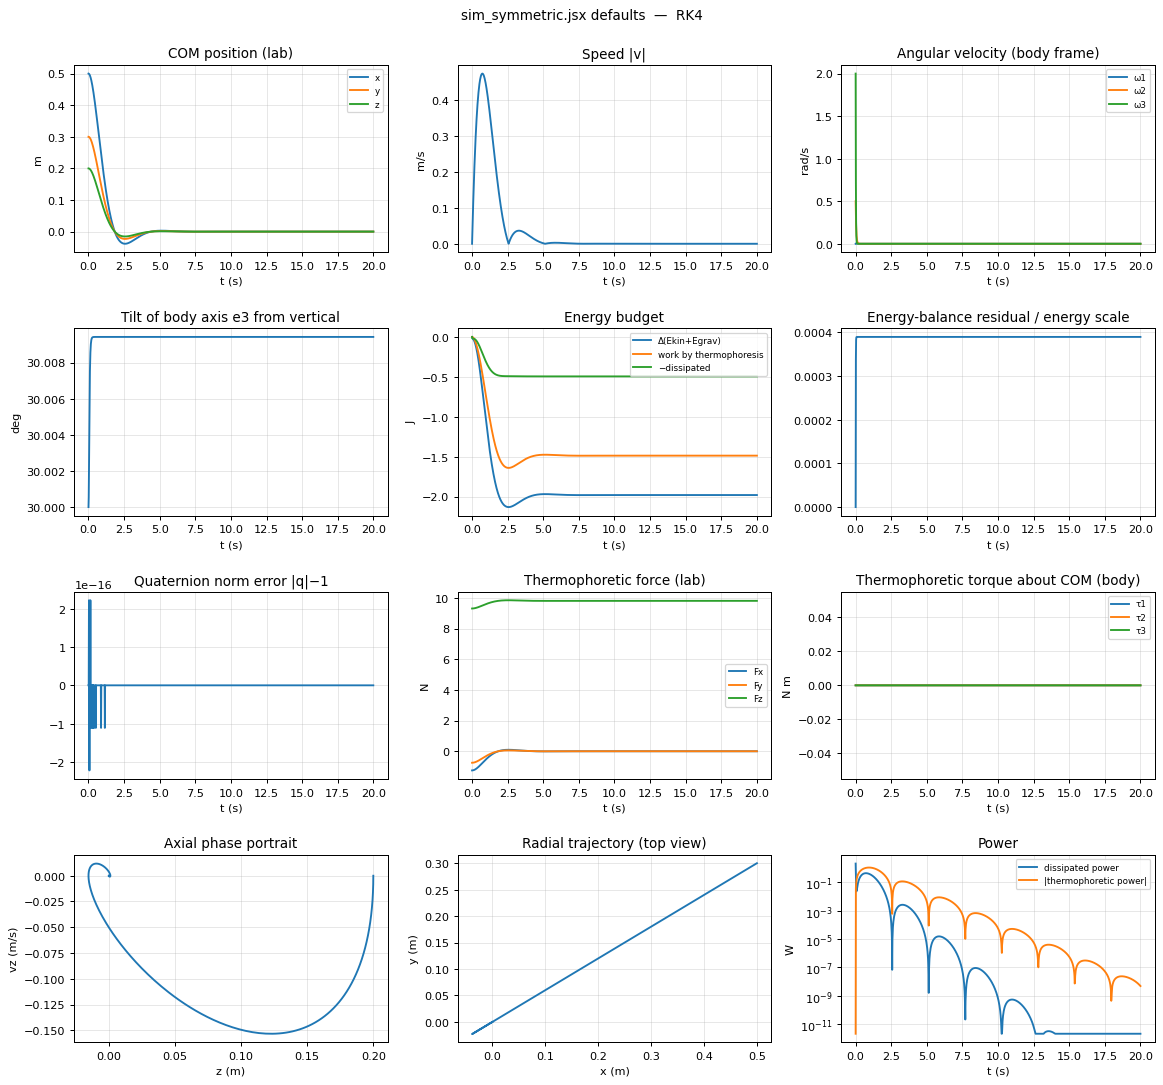

In [14]:
diagnostic_plots(legacy_traj)

In [15]:
legacy_J = linearize(legacy, legacy_env, [0, 0, 0], [1, 0, 0, 0])
mode_table(legacy_J, "Legacy defaults: linear modes about the trap centre")
check_close("oscillator eigenvalue", sorted_eigs(legacy_J)[sorted_eigs(legacy_J).imag > 0.1][0], -1 + 1.2247449j, 1e-6)
print(rk4_stability(legacy_J, legacy_traj.dt))

**Legacy defaults: linear modes about the trap centre**

| eigenvalue (1/s) | decay rate (1/s) | frequency (Hz) | Q | type |
|---|---|---|---|---|
| 0 + 0 i | -0 | 0 | – | neutral |
| 0 + 0 i | -0 | 0 | – | neutral |
| 0 + 0 i | -0 | 0 | – | neutral |
| -1 + 1.22474 i | 1 | 0.1949 | 0.791 | stable |
| -1 − 1.22474 i | 1 | 0.1949 | 0.791 | stable |
| -1 + 1.22474 i | 1 | 0.1949 | 0.791 | stable |
| -1 − 1.22474 i | 1 | 0.1949 | 0.791 | stable |
| -1 + 1.22474 i | 1 | 0.1949 | 0.791 | stable |
| -1 − 1.22474 i | 1 | 0.1949 | 0.791 | stable |
| -25 + 0 i | 25 | 0 | – | stable |
| -25 + 0 i | 25 | 0 | – | stable |
| -62.5 + 0 i | 62.5 | 0 | – | stable |

PASS  oscillator eigenvalue
      got -1.+1.22474487j   expected -1.+1.2247449j   rel. err 1.81e-08
{'dt': 0.016666666666666666, 'max|λ|dt': np.float64(1.0416666666666667), 'max RK4 amplification': np.float64(1.0), 'verdict': 'stable'}


**Why the legacy energy residual is about $4\times10^{-4}$.** This is not a physics error. The JS step $\Delta t=1/60$ s gives $|\lambda\Delta t|=1.04$ for the axial spin-down mode ($\Omega_3/I_3=62.5\ {\rm s^{-1}}$). That value is inside RK4's stability region, but the first few steps carry an error of several per cent in that fast mode, which is visible as the jump at $t\approx0$. The residual therefore falls roughly as $\Delta t^4$ once the step resolves the fast mode. The trajectory itself is dominated by the slow 1.2 s⁻¹ oscillator and is already converged (Section 9.1 matches the analytic solution to $10^{-8}$).

In [16]:
conv = []
for n in [1200, 2400, 4800, 9600]:
    d = trajectory_diagnostics(rk4_simulate(legacy, legacy_env, legacy_traj.s[0, :13], 20, n))
    conv.append((n, 20/n, np.abs(d["E_residual_rel"]).max()))
display(Markdown("| steps | Δt (s) | max relative energy residual |\n|---|---|---|\n" +
                 "\n".join(f"| {n} | {dt:.5f} | {r:.2e} |" for n, dt, r in conv)))
check_close("RK4 order: residual ratio for the last step halving is about 2^4", conv[-2][2]/conv[-1][2], 16, 0.25)

| steps | Δt (s) | max relative energy residual |
|---|---|---|
| 1200 | 0.01667 | 3.90e-04 |
| 2400 | 0.00833 | 1.63e-05 |
| 4800 | 0.00417 | 8.57e-07 |
| 9600 | 0.00208 | 4.92e-08 |

PASS  RK4 order: residual ratio for the last step halving is about 2^4
      got 17.42325826   expected 16   rel. err 8.90e-02


The animation below reproduces the JavaScript UI: a 3-D view with the trajectory trail, plus time-series panels with a cursor. Use the player controls to play, pause and scrub. `interactive_viewer(legacy_traj)` gives live elevation and azimuth sliders. The camera here is moved from the JS default (Elev 25°, Azim 38°), because from that direction the initial offset $(0.5,0.3,0.2)$ points almost straight at the viewer and the trail is foreshortened to a dot.

In [17]:
show_animation(legacy_traj, elev=20, azim=-60)

In [18]:
interactive_viewer(legacy_traj)

[interactive widget: re-run this cell in a live Jupyter kernel with ipywidgets installed]


### 9.2 The $\Gamma_{22}$ offset bug

Take a diagonal but anisotropic $\Gamma={\rm diag}(5,5,8)$ and an upright body. With the legacy offset, the particle settles at $z^*=(Mg/\alpha_z)(1/\Gamma_{22}-1/\Gamma_{33})=1.4715$ m instead of the trap centre. The balanced offset puts it at $z=0$.

In [19]:
aniso = replace(legacy, name="anisotropic Γ", thermo=thermo_from_blocks(diag3(5, 5, 8), Z3))
s00 = initial_state([0, 0, 0], [0, 0, 0], [0, 0, 0])
z_legacy = rk4_simulate(aniso, make_environment(aniso, g0_mode="LegacyJS"), s00, 40, 4000).s[-1, 2]
z_balanced = rk4_simulate(aniso, make_environment(aniso, g0_mode="Balanced"), s00, 40, 4000).s[-1, 2]
check_close("LegacyJS offset: z* = (Mg/az)(1/G22 - 1/G33)", z_legacy, 9.81/0.5*(1/5 - 1/8), 1e-6)
check_abs("Balanced offset: z* = 0", z_balanced, 0, 1e-9)

PASS  LegacyJS offset: z* = (Mg/az)(1/G22 - 1/G33)
      got 1.4715   expected 1.4715   rel. err 1.66e-15
PASS  Balanced offset: z* = 0
      got 0.   expected 0   abs. err 0.00e+00


### 9.3 A polar particle aligns with the gradient (antisymmetric $\Lambda$)

A cone-like body with symmetry axis $\hat{\mathbf e}_3$ has $\Lambda=\lambda_a[\hat{\mathbf e}_3]_\times$. At the trap centre $\mathbf G=-g_0\hat{\mathbf e}_z$, so the torque is $\boldsymbol\tau=\lambda_a g_0\,\hat{\mathbf e}_3\times(R^{\mathsf T}\hat{\mathbf e}_z)$. It turns the body axis toward the vertical with stiffness $k=\lambda_a g_0$. With $\lambda_a=0.05$ the motion is overdamped ($\Omega^2>4Ik$). Dropping the inertia, $\Omega\dot\theta=-k\sin\theta$ gives $\tan(\theta/2)=\tan(\theta_0/2)\,e^{-kt/\Omega}$. The symmetric-$\Lambda$ simulator could not represent this particle at all.

PASS  tilt(t = 5, 10, 20)
      got [24.47845147  9.23039415  1.28022256]   expected [24.478451  9.230394  1.280223]   rel. err 2.53e-08
PASS  tilt(t=10) vs overdamped formula (inertia neglected)
      got 9.23039415   expected 9.28015713   rel. err 5.36e-03


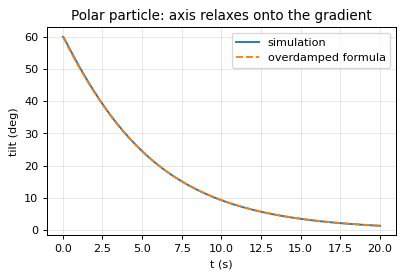

In [20]:
polar = replace(legacy, name="polar (C∞v) particle", thermo=thermo_from_blocks(iso3(5.0), 0.05*skew([0, 0, 1])))
polar_env = make_environment(polar)
polar_traj = rk4_simulate(polar, polar_env, initial_state([0, 0, 0], [0, 0, 0], [0, 0, 0], 60), 20, 1200)
k_align = 0.05*np.linalg.norm(polar_env.G0)
overdamped = lambda t: np.degrees(2*np.arctan(np.tan(np.radians(30))*np.exp(-k_align*t/0.5)))
tilts = np.array([tilt_deg(s[6:10]) for s in polar_traj.s])
check_close("tilt(t = 5, 10, 20)", tilts[[300, 600, 1200]], [24.478451, 9.230394, 1.280223], 1e-5)
check_close("tilt(t=10) vs overdamped formula (inertia neglected)", tilts[600], overdamped(10.0), 1e-2)
plt.figure(figsize=(5, 3)); plt.plot(polar_traj.t, tilts, label="simulation")
plt.plot(polar_traj.t, overdamped(polar_traj.t), "--", label="overdamped formula")
plt.xlabel("t (s)"); plt.ylabel("tilt (deg)"); plt.title("Polar particle: axis relaxes onto the gradient"); plt.legend(); plt.show()

### 9.4 A chiral particle: coupling block $B$ and symmetric $\Lambda$

A helix-like body can have $B=b\,\mathbb I$, so translating makes it rotate, and $\Lambda=\lambda_c\mathbb I$, so a gradient makes it spin. The background gradient never vanishes, so the particle settles into **steady spin** about the vertical. Setting $\mathbf v=0$ and $\boldsymbol\omega=\omega\hat{\mathbf e}_z$ in the 6×6 balance gives

$$G_z=\frac{Mg}{b\lambda_c/\Omega-\gamma},\qquad \omega=-\frac{\lambda_c}{\Omega}G_z,\qquad z^*=\frac{G_z+g_0}{\alpha_z}.$$

The spin also feeds back on the force through $B$ and shifts the height slightly.

**chiral (D∞) particle**

| check | status | value |
|---|---|---|
| Res is 6x6 and Thermo is 6x3 | OK |  |
| Res symmetric (reciprocal theorem): |R-R^T|/|R| | OK | 0.0e+00 |
| Res positive definite (second law): min eig of scaled R | OK | 0.7 |
| Inertia symmetric | OK |  |
| Inertia positive definite | OK | [0.02  0.02  0.008] |
| Principal moments obey I1 <= I2 + I3 | OK |  |
| Mass > 0 | OK | 1 |

PASS  steady spin rate
      got 0.39716599   expected 0.39716599   rel. err 3.14e-09
PASS  steady height
      got -0.04765992   expected -0.04765992   rel. err 8.26e-08


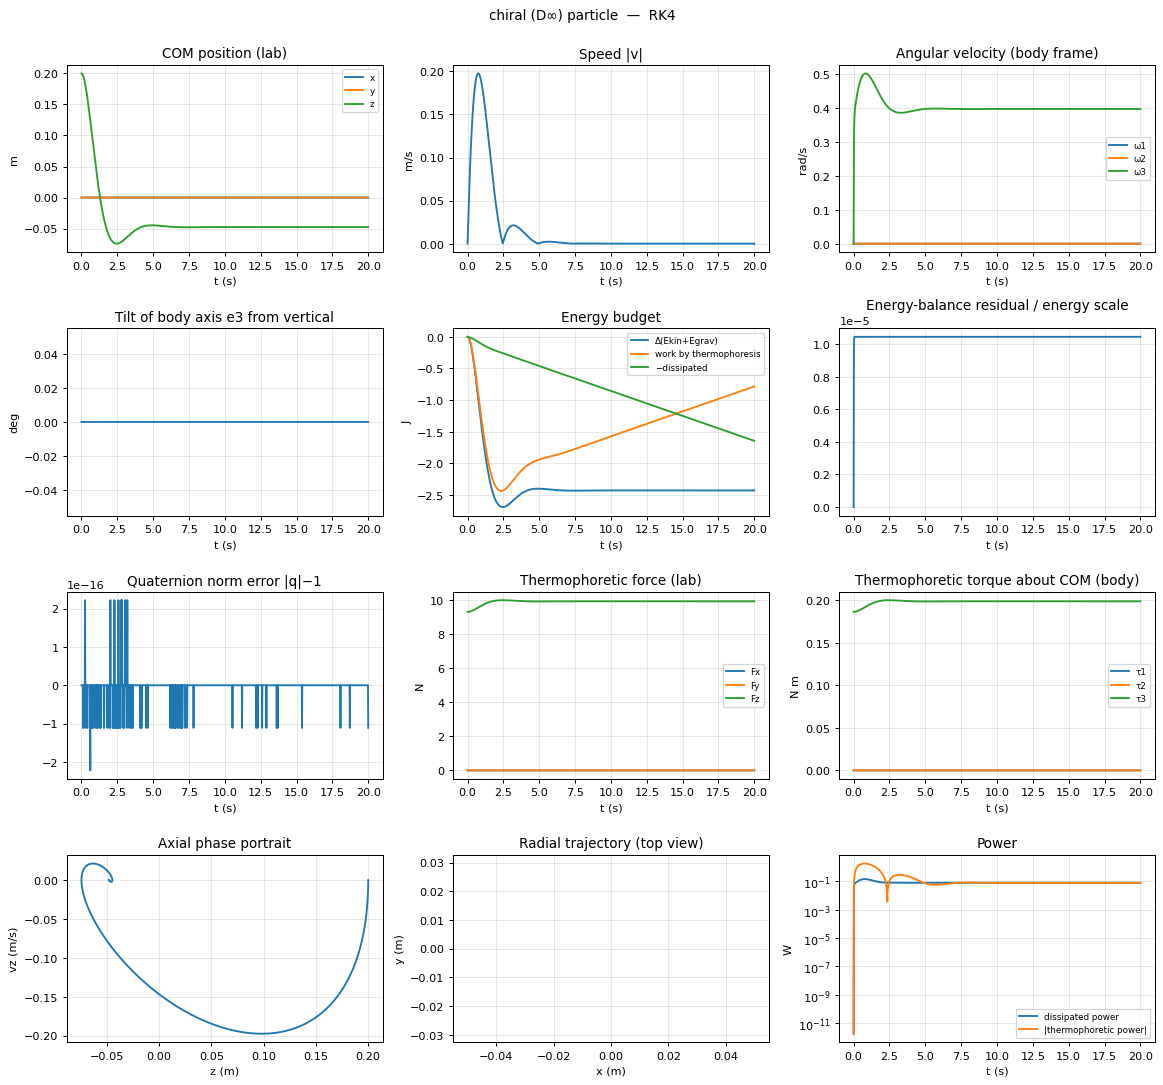

In [21]:
chiral = replace(legacy, name="chiral (D∞) particle",
                 res=resistance_from_blocks(iso3(2.0), iso3(0.3), iso3(0.5)),
                 thermo=thermo_from_blocks(iso3(5.0), iso3(0.1)))
validate_particle(chiral)
chiral_env = make_environment(chiral)
chiral_traj = rk4_simulate(chiral, chiral_env, initial_state([0, 0, 0.2], [0, 0, 0], [0, 0, 0]), 20, 1200)
Gz = 9.81/(0.3*0.1/0.5 - 5.0)
check_close("steady spin rate", chiral_traj.s[-1, 12], -0.1/0.5*Gz, 1e-5)
check_close("steady height", chiral_traj.s[-1, 2], (Gz + np.linalg.norm(chiral_env.G0))/0.5, 1e-4)
diagnostic_plots(chiral_traj)

## 10. Particle library

This section computes $M$, $I$, $\mathcal R_H$, $\mathcal T_H$ and $\mathbf r_H$ from geometry, material and gas properties. The default gas is air at $T_0=260$ K and $p=1$ Torr. The default material is ice, with $\rho_p=917\ {\rm kg/m^3}$ and $k_p=2.2$ W/(m K). Every builder returns a `Particle`, so it can be passed straight to `make_environment`, the integrators and the diagnostics. New types are added with `register_particle_type` (Section 10.7).

Schematics of the trap and of the three current particle types, with the parameters that control them, are in `figures/particle_diagrams.pdf` (source `particle_diagrams.tex`). The cell below rasterises the PDF with `pdftoppm` (from poppler) if it is installed.

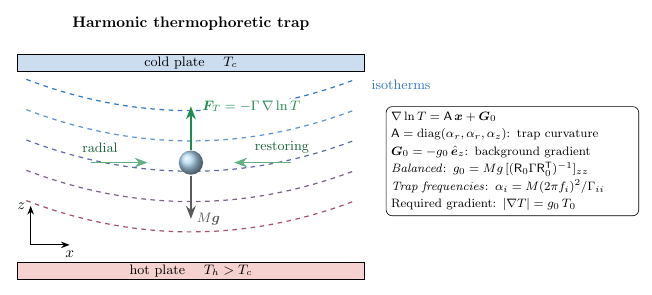

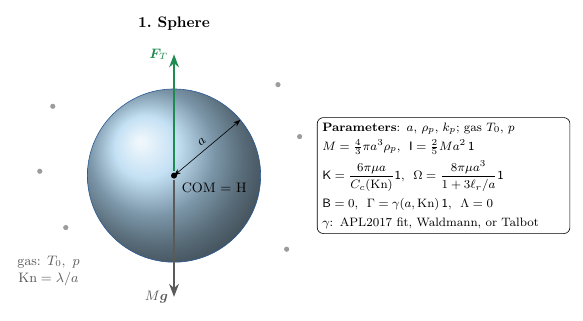

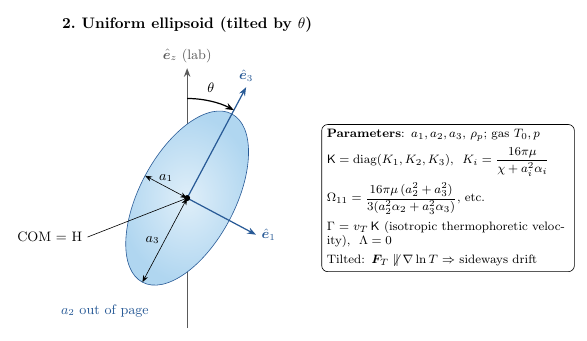

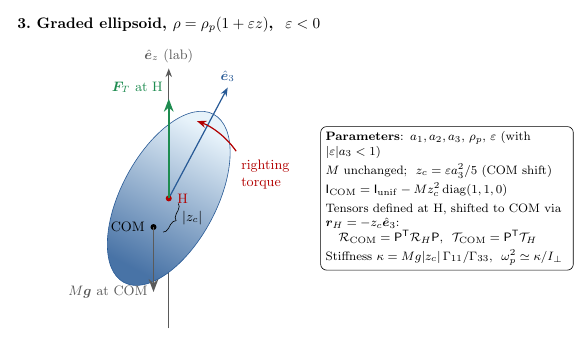

In [22]:
import shutil, subprocess, tempfile
from IPython.display import Image
pdf = FIG_DIR / "particle_diagrams.pdf"
if pdf.exists() and shutil.which("pdftoppm"):
    with tempfile.TemporaryDirectory() as tmp:
        subprocess.run(["pdftoppm", "-png", "-r", "110", str(pdf), f"{tmp}/page"], check=True)
        for png in sorted(Path(tmp).glob("page*.png")):
            display(Image(filename=str(png)))
else:
    print(f"Open {pdf} directly (pdftoppm not found, or run `latexmk -pdf particle_diagrams.tex` in figures/).")

### 10.1 Gas properties

The gas model follows the lab's legacy code (`Theory/thermophoreticforce.py`): the same molecular mass and the same fitted $\kappa(T)$. The viscosity comes from Sutherland's law. Two mean free paths appear:

* the viscosity-based $\lambda_\mu=(\mu/p)\sqrt{\pi k_BT/2m}$, used for drag;
* the conductivity-based $\lambda_\kappa=(4\kappa/5p)\sqrt{mT/2k_B}$, used by the legacy thermophoresis fit, because that fit was calibrated with it.

In [23]:
KB, M_AIR, TORR = 1.380649e-23, 4.809e-26, 133.322

def gas_properties(T, p_torr):
    p = p_torr*TORR
    mu = 1.716e-5*(T/273.15)**1.5*(273.15 + 110.4)/(T + 110.4)
    kap = 0.00119 + 8.94685e-5*T - 2.18293e-8*T**2
    rho = p*M_AIR/(KB*T)
    return dict(T=T, p_torr=p_torr, p=p, mu=mu, kappa=kap, rho=rho, vbar=np.sqrt(8*KB*T/(np.pi*M_AIR)),
                lambda_mu=mu/p*np.sqrt(np.pi*KB*T/(2*M_AIR)), lambda_kappa=4*kap/(5*p)*np.sqrt(M_AIR*T/(2*KB)),
                kappa_tr=15/4*KB/M_AIR*mu, nu=mu/rho)

GAS_DEFAULT = gas_properties(260.0, 1.0)
display(Markdown("| quantity | value |\n|---|---|\n" + "\n".join(f"| {k} | {v:.6g} |" for k, v in GAS_DEFAULT.items())))
check_close("mu, kappa, rho, vbar, lambda_mu, lambda_kappa (260 K, 1 Torr)",
            np.array([GAS_DEFAULT[k] for k in ["mu", "kappa", "rho", "vbar", "lambda_mu", "lambda_kappa"]]) /
            np.array([1.65016172e-5, 0.0229761493, 1.78607613e-3, 435.984434, 4.23824006e-5, 9.27732638e-5]), np.ones(6), 1e-7)

| quantity | value |
|---|---|
| T | 260 |
| p_torr | 1 |
| p | 133.322 |
| mu | 1.65016e-05 |
| kappa | 0.0229761 |
| rho | 0.00178608 |
| vbar | 435.984 |
| lambda_mu | 4.23824e-05 |
| lambda_kappa | 9.27733e-05 |
| kappa_tr | 0.0177659 |
| nu | 0.00923903 |

PASS  mu, kappa, rho, vbar, lambda_mu, lambda_kappa (260 K, 1 Torr)
      got [1. 1. 1. 1. 1. 1.]   expected [1. 1. 1. 1. 1. 1.]   rel. err 1.08e-09


### 10.2 Spheres

* **Mass and inertia:** $M=\tfrac43\pi a^3\rho_p$ and $I=\tfrac25Ma^2\,\mathbb I$. The centre is a symmetry point, so $\mathbf r_H=0$, $B=0$ and $\Lambda=0$.
* **Translational drag:** $K=6\pi\mu a/C_c({\rm Kn})$, with the Cunningham–Davies correction $C_c=1+{\rm Kn}\,(1.257+0.4e^{-1.1/{\rm Kn}})$ and ${\rm Kn}=\lambda_\mu/a$. This interpolates between the Stokes and Epstein limits.
* **Rotational drag:** slip flow gives $\Omega=8\pi\mu a^3/(1+3\ell_r/a)$. In the free-molecular limit, diffuse re-emission carries away the wall's tangential momentum at the rate $\tfrac14 n\bar v\,m u_w$ per unit area, so $\Omega_{\rm fm}=\tfrac{2\pi}{3}\rho\bar v a^4$. Choosing $\ell_r=4\mu/(\rho\bar v)$ makes the interpolation exact in **both** limits.
* **Thermophoretic force** ($\mathbf F=-\Gamma\nabla\ln T$, with $\Gamma$ in N·m). Three models:
  * `"APL2017"` (default) is the fit used in the lab's 2017 APL code: $F=-f_T({\rm Kn}_\kappa)\,a^2\kappa\nabla T/\sqrt{2k_BT/m}$, with $f_T=9{\rm Kn}^3/\bigl((1+4.4844{\rm Kn}^2)(1+{\rm Kn})\bigr)$. Hence $\Gamma=f_Ta^2\kappa T/\sqrt{2k_BT/m}$.
  * `"Waldmann"` is the free-molecular limit, $\Gamma=\tfrac{32}{15}a^2\kappa_{\rm tr}T/\bar v$, with the translational conductivity $\kappa_{\rm tr}=\tfrac{15}{4}(k_B/m)\mu$.
  * `"Talbot"` (Talbot *et al.* 1980) interpolates from the continuum to the transition regime: $\Gamma=12\pi\mu\nu a\,C_s(k_g/k_p+C_t{\rm Kn})/\bigl((1+3C_m{\rm Kn})(1+2k_g/k_p+2C_t{\rm Kn})\bigr)$, with $C_s=1.17$, $C_t=2.18$, $C_m=1.14$. It depends on the particle's thermal conductivity $k_p$.

In [24]:
def cunningham(kn):          return 1 + kn*(1.257 + 0.4*np.exp(-1.1/kn))
def rot_slip_length(gas):    return 4*gas["mu"]/(gas["rho"]*gas["vbar"])
def sphere_drag(a, gas):
    return 6*np.pi*gas["mu"]*a/cunningham(gas["lambda_mu"]/a), 8*np.pi*gas["mu"]*a**3/(1 + 3*rot_slip_length(gas)/a)
def f_T_2017(kn):            return 9*kn**3/((1 + 4.4844*kn**2)*(1 + kn))

def sphere_gamma(a, gas, model="APL2017", kp=2.2):
    if model == "APL2017":
        return f_T_2017(gas["lambda_kappa"]/a)*a**2*gas["kappa"]*gas["T"]/np.sqrt(2*KB*gas["T"]/M_AIR)
    if model == "Waldmann":
        return 32/15*a**2*gas["kappa_tr"]*gas["T"]/gas["vbar"]
    if model == "Talbot":
        kn, cs, ct, cm, kr = gas["lambda_mu"]/a, 1.17, 2.18, 1.14, gas["kappa"]/kp
        return 12*np.pi*gas["mu"]*gas["nu"]*a*cs*(kr + ct*kn)/((1 + 3*cm*kn)*(1 + 2*kr + 2*ct*kn))
    raise ValueError(f"unknown thermophoresis model {model!r}")

### 10.3 Ellipsoids

**Stokes resistance** (Oberbeck; Edwardes–Jeffery), for semi-axes $a_1,a_2,a_3$ along the body axes:

$$\chi=\int_0^\infty\frac{d\lambda}{\Delta},\qquad \alpha_i=\int_0^\infty\frac{d\lambda}{(a_i^2+\lambda)\Delta},\qquad \Delta=\sqrt{(a_1^2+\lambda)(a_2^2+\lambda)(a_3^2+\lambda)},$$

$$K_{ii}=\frac{16\pi\mu}{\chi+a_i^2\alpha_i},\qquad \Omega_{11}=\frac{16\pi\mu\,(a_2^2+a_3^2)}{3(a_2^2\alpha_2+a_3^2\alpha_3)}\quad\text{(and cyclic)}.$$

The integrals are Carlson symmetric elliptic integrals, $\chi=2R_F(a_1^2,a_2^2,a_3^2)$ and $\alpha_i=\tfrac23R_D(a_j^2,a_k^2,a_i^2)$. They are evaluated in units of the volume-equivalent radius $a_{\rm eq}=(a_1a_2a_3)^{1/3}$ and checked against direct quadrature and against the closed-form spheroid results of Kim & Karrila. The centre is a symmetry point, so $B=0$ and $\Lambda=0$ there.

**Rarefaction (approximate).** The continuum shape tensors are divided by the *sphere-equivalent* corrections $C_c(\lambda_\mu/a_{\rm eq})$ and $1+3\ell_r/a_{\rm eq}$. This is exact for spheres. For strongly non-spherical bodies at ${\rm Kn}\gtrsim1$ the free-molecular anisotropy differs from the continuum one; replace the builder when better data exist.

**Thermophoresis (isotropic thermophoretic-velocity approximation).** Take $\mathcal T_H=v_T\,\mathcal R_H[:,1{:}3]$: the thermophoretic wrench equals the drag the body would feel moving at velocity $v_T\nabla\ln T$. Then a *free* particle drifts at $-v_T\nabla\ln T$ in every orientation and does not rotate. This holds exactly in the continuum limit for a non-conducting particle with thermal-creep slip. The argument is the same one that makes Smoluchowski electrophoresis independent of shape (Morrison 1970). The scalar $v_T=\Gamma_{\rm sphere}(a_{\rm eq})/K_{\rm sphere}(a_{\rm eq})$ comes from the chosen sphere model. Because $\Gamma=v_TK$ inherits the anisotropy of $K$, a tilted body feels a force that is not parallel to $\nabla T$.

In [25]:
def ellipsoid_integrals(b):
    b2 = np.asarray(b, float)**2
    chi = 2*elliprf(*b2)
    al = np.array([2/3*elliprd(b2[(i+1) % 3], b2[(i+2) % 3], b2[i]) for i in range(3)])
    return chi, al

def ellipsoid_stokes(axes, mu):
    axes = np.asarray(axes, float); aeq = np.prod(axes)**(1/3); b = axes/aeq
    chi, al = ellipsoid_integrals(b)
    K = 16*np.pi*mu*aeq/(chi + b**2*al)
    Om = np.array([16*np.pi*mu*aeq**3*(b[j]**2 + b[k]**2)/(3*(b[j]**2*al[j] + b[k]**2*al[k]))
                   for j, k in [(1, 2), (2, 0), (0, 1)]])
    return K, Om

def prolate_coefficients(aspect):
    e = np.sqrt(1 - 1/aspect**2); L = np.log((1 + e)/(1 - e))
    return dict(XA=8/3*e**3/(-2*e + (1 + e**2)*L), YA=16/3*e**3/(2*e + (3*e**2 - 1)*L),
                XC=4/3*e**3*(1 - e**2)/(2*e - (1 - e**2)*L), YC=4/3*e**3*(2 - e**2)/(-2*e + (1 + e**2)*L))

In [26]:
b = np.array([0.7, 1.1, 1.9]); D = lambda l: np.sqrt(np.prod(b**2 + l))
chi_q = quad(lambda l: 1/D(l), 0, np.inf, epsabs=0, epsrel=1e-12, limit=200)[0]
al_q = [quad(lambda l, bi=bi: 1/((bi**2 + l)*D(l)), 0, np.inf, epsabs=0, epsrel=1e-12, limit=200)[0] for bi in b]
check_close("Carlson integrals vs direct quadrature (triaxial)", np.concatenate([[ellipsoid_integrals(b)[0]], ellipsoid_integrals(b)[1]]), [chi_q, *al_q], 1e-9)
K, Om = ellipsoid_stokes([1, 1, 1], 1.0)
check_close("sphere limit K/(6 pi mu a), Omega/(8 pi mu a^3)", np.concatenate([K/(6*np.pi), Om/(8*np.pi)]), np.ones(6), 1e-12)
K, Om = ellipsoid_stokes([1, 1, 2], 1.0); pc = prolate_coefficients(2.0)
check_close("2:1 prolate: X^A, Y^A, X^C, Y^C", [K[2]/(12*np.pi), K[0]/(12*np.pi), Om[2]/(64*np.pi), Om[0]/(64*np.pi)],
            [pc["XA"], pc["YA"], pc["XC"], pc["YC"]], 1e-10)
check_close("Kim & Karrila values for 2:1 prolate", list(pc.values()), [0.6019705, 0.6894495, 0.2016692, 0.3762316], 1e-6)

PASS  Carlson integrals vs direct quadrature (triaxial)
      got [1.65039373 0.71784213 0.43541824 0.21379363]   expected [1.65039373 0.71784213 0.43541824 0.21379363]   rel. err 8.47e-16
PASS  sphere limit K/(6 pi mu a), Omega/(8 pi mu a^3)
      got [1. 1. 1. 1. 1. 1.]   expected [1. 1. 1. 1. 1. 1.]   rel. err 0.00e+00
PASS  2:1 prolate: X^A, Y^A, X^C, Y^C
      got [0.60197049 0.68944953 0.20166917 0.37623156]   expected [0.60197049 0.68944953 0.20166917 0.37623156]   rel. err 1.55e-16
PASS  Kim & Karrila values for 2:1 prolate
      got [0.60197049 0.68944953 0.20166917 0.37623156]   expected [0.6019705 0.6894495 0.2016692 0.3762316]   rel. err 5.54e-08


### 10.4 Ellipsoid with a linear density gradient

Let the density be $\rho=\rho_p(1+\varepsilon z)$ in body coordinates, with $|\varepsilon|a_3<1$ so that it stays positive. Every moment of the uniform ellipsoid that is odd in $z$ vanishes, which gives exact results:

* **Mass is unchanged:** $M=\tfrac43\pi a_1a_2a_3\rho_p$.
* **The centre of mass moves along $\hat{\mathbf e}_3$:** $z_c=\varepsilon\langle z^2\rangle=\varepsilon a_3^2/5$.
* **The inertia about the geometric centre is unchanged:** each component of $\int\varepsilon z\,(r^2\delta_{ij}-r_ir_j)\,dV$ is odd in some coordinate. The parallel-axis theorem then gives $I_{\rm COM}=I_{\rm unif}-Mz_c^2\,{\rm diag}(1,1,0)$.
* **The force centre stays at the geometric centre**, because the shape and surface are unchanged. So $\mathcal R_H$ and $\mathcal T_H$ equal those of the uniform ellipsoid, and $\mathbf r_H=-z_c\hat{\mathbf e}_3$. The shift of Section 3.3 then generates the coupling terms automatically.

**Righting torque.** Tilt the body by $\theta$ at the balanced equilibrium. The body-frame gradient then has a transverse component $g_0\sin\theta$, so the transverse thermophoretic force is $\Gamma_{11}g_0\sin\theta$. It acts at H, a distance $|z_c|$ from the COM:

$$\tau=-\kappa\sin\theta,\qquad \kappa=Mg\,|z_c|\,\frac{\Gamma_{11}}{\Gamma_{33}},\qquad \omega_p^2\simeq\frac{\kappa}{I_{\perp,\rm COM}} .$$

The ratio $\Gamma_{11}/\Gamma_{33}$ is the anisotropy correction; it equals 1 for a sphere. With $\varepsilon<0$ the heavy end is at $-z$, so the upright orientation (tilt 0) is stable. With $\varepsilon>0$ the stable orientation is inverted (tilt 180°).

In [27]:
def graded_ellipsoid_particle(semiaxes, epsilon=0.0, epsilon_a3=None, density=917.0, gas=None,
                              thermo_model="APL2017", kp=2.2, name=None):
    gas = GAS_DEFAULT if gas is None else gas
    ax = np.asarray(semiaxes, float); a1, a2, a3 = ax
    eps = epsilon_a3/a3 if epsilon_a3 is not None else float(epsilon)
    if abs(eps)*a3 >= 1: raise ValueError(f"density must stay positive: need |eps| a3 < 1 (got {eps*a3})")
    aeq = np.prod(ax)**(1/3)
    if np.allclose(ax, a1, rtol=1e-14):
        K0, Om0 = np.full(3, 6*np.pi*gas["mu"]*a1), np.full(3, 8*np.pi*gas["mu"]*a1**3)
    else:
        K0, Om0 = ellipsoid_stokes(ax, gas["mu"])
    kn = gas["lambda_mu"]/aeq
    K, Om = K0/cunningham(kn), Om0/(1 + 3*rot_slip_length(gas)/aeq)
    vT = sphere_gamma(aeq, gas, thermo_model, kp)/sphere_drag(aeq, gas)[0]
    res = resistance_from_blocks(np.diag(K), Z3, np.diag(Om))
    M = 4/3*np.pi*a1*a2*a3*density
    zc = eps*a3**2/5
    inertia = M/5*np.diag([a2**2 + a3**2, a3**2 + a1**2, a1**2 + a2**2]) - M*zc**2*np.diag([1, 1, 0])
    kind = "Graded ellipsoid" if eps != 0 else ("Sphere" if np.allclose(ax, a1) else "Ellipsoid")
    auto = f"{kind} {'/'.join(f'{1e6*a:.3g}' for a in ax)} µm" + (f", ε·a3 = {eps*a3:.3g}" if eps else "")
    return Particle(name or auto, M, inertia, res, vT*res[:, :3], rH=[0, 0, -zc],
                    shape={"type": "ellipsoid", "semiaxes": ax, "epsilon": eps},
                    meta=dict(kind=kind, aeq=aeq, Kn=kn, vT=vT, zc=zc, epsilon=eps, density=density,
                              thermo_model=thermo_model, gas=gas, length_scale=ax.max()))

def sphere_particle(radius, **kw):     return graded_ellipsoid_particle([radius]*3, epsilon=0.0, **kw)
def ellipsoid_particle(semiaxes, **kw): return graded_ellipsoid_particle(semiaxes, epsilon=0.0, **kw)
def righting_stiffness(p, g=9.81):     return p.mass*g*abs(p.meta["zc"])*p.thermo[0, 0]/p.thermo[2, 2]

### 10.5 Library registry, summaries and diagrams

`particle_diagram` draws the particle's $x$–$z$ cross-section from its actual parameters. It shows the density shading, the COM, the force centre H, the offset $\mathbf r_H$, the semi-axes, and the force pair that produces the righting torque. It is meant as a quick visual check of a particle definition.

In [28]:
PARTICLE_LIBRARY = {
    "Sphere":          dict(builder=sphere_particle, parameters=["radius", "density", "gas", "thermo_model", "kp"],
                            description="Homogeneous sphere of radius a (m)."),
    "Ellipsoid":       dict(builder=ellipsoid_particle, parameters=["semiaxes", "density", "gas", "thermo_model", "kp"],
                            description="Homogeneous triaxial ellipsoid, semi-axes (a1, a2, a3) in m along body axes."),
    "GradedEllipsoid": dict(builder=graded_ellipsoid_particle,
                            parameters=["semiaxes", "epsilon (1/m) or epsilon_a3", "density", "gas", "thermo_model", "kp"],
                            description="Ellipsoid with density rho (1 + eps z); COM displaced from the force centre."),
}
def register_particle_type(name, builder, parameters, description):
    PARTICLE_LIBRARY[name] = dict(builder=builder, parameters=parameters, description=description)
def build_particle(kind, **params):
    return PARTICLE_LIBRARY[kind]["builder"](**params)

def particle_summary(p):
    Rc, Tc = p.at_com(); m = p.meta
    rows = [("mass (kg)", f"{p.mass:.5e}"), ("principal moments about COM (kg m²)", np.array2string(np.sort(np.linalg.eigvalsh(p.inertia)), precision=4)),
            ("diag K (N s/m)", np.array2string(np.diag(p.res)[:3], precision=5)), ("diag Ω (N m s)", np.array2string(np.diag(p.res)[3:], precision=5)),
            ("diag Γ (N m)", np.array2string(np.diag(p.thermo[:3]), precision=5)), ("r_H: COM → force centre (m)", np.array2string(p.rH, precision=4)),
            ("Knudsen number (a_eq)", f"{m.get('Kn', float('nan')):.4g}"), ("thermophoretic velocity scale v_T (m²/s)", f"{m.get('vT', float('nan')):.4g}"),
            ("translational relaxation M/K (s)", f"{p.mass/p.res[0, 0]:.4g}"), ("rotational relaxation I/Ω (s)", f"{p.inertia[0, 0]/p.res[3, 3]:.4g}")]
    display(Markdown(f"**{p.name}**\n\n| quantity | value |\n|---|---|\n" + "\n".join(f"| {a} | {b} |" for a, b in rows)))
    show_matrix(Rc, r"$\mathcal R_{\rm COM}=$"); show_matrix(Tc, r"$\mathcal T_{\rm COM}=$")

def particle_diagram(p, ax=None, tilt=0.0):
    s = p.shape; a1, _, a3 = s["semiaxes"]; eps = s.get("epsilon", 0.0); L = max(a1, a3); u = 1e6
    ax = ax or plt.figure(figsize=(3.4, 4)).gca()
    c, sn = np.cos(np.radians(tilt)), np.sin(np.radians(tilt))
    rot = lambda X, Z: (c*X + sn*Z, -sn*X + c*Z)        # body x-z plane -> lab x-z plane, tilt about y
    X, Z = np.meshgrid(np.linspace(-a1, a1, 200), np.linspace(-a3, a3, 200))
    inside = (X/a1)**2 + (Z/a3)**2 <= 1
    dens = np.where(inside, 1 + eps*Z, np.nan)
    Xl, Zl = rot(X, Z)
    ax.pcolormesh(u*Xl, u*Zl, dens, cmap="Blues", vmin=1 - 1.6*max(abs(eps)*a3, 0.3), vmax=1 + 1.2*max(abs(eps)*a3, 0.3), shading="auto")
    t = np.linspace(0, 2*np.pi, 200); ex, ez = rot(a1*np.cos(t), a3*np.sin(t)); ax.plot(u*ex, u*ez, color="navy", lw=1)
    H, C = np.array(rot(0, 0)), np.array(rot(0, -p.rH[2]))
    ax.plot(*(u*H), "o", color="red", ms=5, label="force centre H"); ax.plot(*(u*C), "ko", ms=5, label="COM")
    if np.linalg.norm(p.rH) > 0:
        ax.annotate("", xy=u*H, xytext=u*C, arrowprops=dict(arrowstyle="->", color="k"))
    e_lo, e_hi = np.array(rot(0, -1.3*a3)), np.array(rot(0, 1.3*a3))
    ax.plot(*(u*np.stack([e_lo, e_hi], 1)), color="blue", ls=":", lw=1)
    ax.text(*(u*e_hi*1.04), r"$\hat e_3$", color="blue", ha="center")
    ax.annotate("", xy=u*(H + [0, 1.3*L]), xytext=u*H, arrowprops=dict(arrowstyle="-|>", color="green", lw=2))
    ax.annotate("", xy=u*(C - [0, 1.3*L]), xytext=u*C, arrowprops=dict(arrowstyle="-|>", color="dimgray", lw=2))
    ax.text(*(u*(H + [-0.1*L, 1.2*L])), r"$\mathbf{F}_T$", color="green", ha="right")
    ax.text(*(u*(C + [-0.1*L, -1.25*L])), r"$M\mathbf{g}$", color="dimgray", ha="right")
    ax.set_aspect("equal"); ax.set_xlabel("x (µm)"); ax.set_ylabel("z (µm)")
    ax.set_xlim(-1.6*u*L, 1.6*u*L); ax.set_ylim(-1.7*u*L, 1.8*u*L); ax.legend(fontsize=6, loc="lower right")
    ax.set_title(f"{p.name}\n$a_1$={u*a1:.3g} µm, $a_3$={u*a3:.3g} µm, $|z_c|$={u*abs(p.meta.get('zc', 0)):.3g} µm", fontsize=8)
    return ax

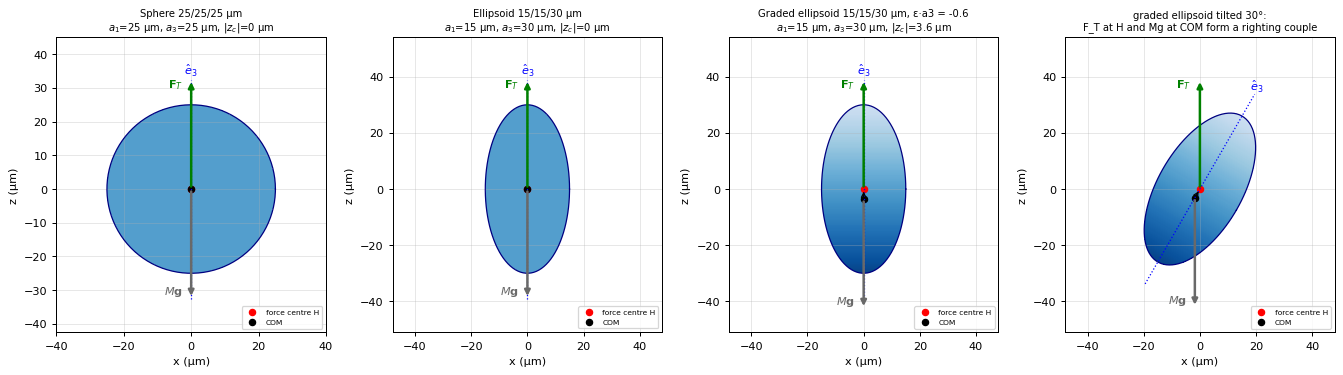

In [29]:
sphere25 = build_particle("Sphere", radius=25e-6)
prolate = build_particle("Ellipsoid", semiaxes=[15e-6, 15e-6, 30e-6])
graded = build_particle("GradedEllipsoid", semiaxes=[15e-6, 15e-6, 30e-6], epsilon_a3=-0.6)
fig, axs = plt.subplots(1, 4, figsize=(15, 4.2))
particle_diagram(sphere25, axs[0]); particle_diagram(prolate, axs[1]); particle_diagram(graded, axs[2]); particle_diagram(graded, axs[3], tilt=30)
axs[3].set_title("graded ellipsoid tilted 30°:\nF_T at H and Mg at COM form a righting couple", fontsize=8)
fig.tight_layout(); plt.show()

In [30]:
check_close("sphere: M, K, Omega, Gamma",
            np.array([sphere25.mass, sphere25.res[0, 0], sphere25.res[3, 3], sphere25.thermo[0, 0]]) /
            [6.0017510e-11, 2.2310782e-9, 5.8004831e-19, 1.5033245e-11], np.ones(4), 1e-6)
check_close("sphere: Waldmann and Talbot Gamma",
            np.array([sphere_gamma(25e-6, GAS_DEFAULT, "Waldmann"), sphere_gamma(25e-6, GAS_DEFAULT, "Talbot")]) /
            [1.4126266e-11, 1.0895402e-11], np.ones(2), 1e-6)
check_close("prolate: diag K", np.diag(prolate.res)[:3]/[1.472811964e-9, 1.472811964e-9, 1.285937998e-9], np.ones(3), 1e-7)
check_close("prolate: diag Omega", np.diag(prolate.res)[3:]/[2.914405838e-19, 2.914405838e-19, 1.562191703e-19], np.ones(3), 1e-7)
check_close("prolate: diag Gamma", np.diag(prolate.thermo[:3])/[9.984101919e-12, 9.984101919e-12, 8.717294777e-12], np.ones(3), 1e-7)
check_close("graded: z_c = eps a3^2 / 5", graded.meta["zc"], -3.6e-6, 1e-9)
check_close("graded: diag I about COM", np.diag(graded.inertia)/[5.497680707e-21, 5.497680707e-21, 2.333480775e-21], np.ones(3), 1e-7)
check_close("graded: mass unchanged by the gradient", graded.mass, prolate.mass, 1e-12)
Rc, Tc = graded.at_com()
check_close("graded: coupling block B_COM = -K [r_H]x", Rc[:3, 3:], -graded.res[:3, :3] @ skew(graded.rH), 1e-12)
check_close("graded: Lambda_COM = [r_H]x Gamma", Tc[3:], skew(graded.rH) @ graded.Gamma, 1e-12)

PASS  sphere: M, K, Omega, Gamma
      got [0.99999999 0.99999999 1.         1.        ]   expected [1. 1. 1. 1.]   rel. err 6.88e-09
PASS  sphere: Waldmann and Talbot Gamma
      got [1. 1.]   expected [1. 1.]   rel. err 3.30e-09
PASS  prolate: diag K
      got [1. 1. 1.]   expected [1. 1. 1.]   rel. err 2.70e-10
PASS  prolate: diag Omega
      got [1. 1. 1.]   expected [1. 1. 1.]   rel. err 1.55e-10
PASS  prolate: diag Gamma
      got [1. 1. 1.]   expected [1. 1. 1.]   rel. err 3.65e-11
PASS  graded: z_c = eps a3^2 / 5
      got -3.6e-06   expected -3.6e-06   rel. err 1.18e-16
PASS  graded: diag I about COM
      got [1. 1. 1.]   expected [1. 1. 1.]   rel. err 9.43e-11
PASS  graded: mass unchanged by the gradient
      got 2.59275642e-11   expected 2.59275642e-11   rel. err 0.00e+00
PASS  graded: coupling block B_COM = -K [r_H]x
      got [[ 0.00000000e+00  5.30212307e-15  0.00000000e+00]
 [-5.30212307e-15  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000

In [31]:
particle_summary(sphere25)
particle_summary(graded)
validate_particle(graded);

**Sphere 25/25/25 µm**

| quantity | value |
|---|---|
| mass (kg) | 6.00175e-11 |
| principal moments about COM (kg m²) | [1.5004e-20 1.5004e-20 1.5004e-20] |
| diag K (N s/m) | [2.23108e-09 2.23108e-09 2.23108e-09] |
| diag Ω (N m s) | [5.80048e-19 5.80048e-19 5.80048e-19] |
| diag Γ (N m) | [1.50332e-11 1.50332e-11 1.50332e-11] |
| r_H: COM → force centre (m) | [ 0.  0. -0.] |
| Knudsen number (a_eq) | 1.695 |
| thermophoretic velocity scale v_T (m²/s) | 0.006738 |
| translational relaxation M/K (s) | 0.0269 |
| rotational relaxation I/Ω (s) | 0.02587 |

$\mathcal R_{\rm COM}=$ $\begin{pmatrix}2.231\mathrm{e}-09 & 0 & 0 & 0 & 0 & 0 \\ 0 & 2.231\mathrm{e}-09 & 0 & 0 & 0 & 0 \\ 0 & 0 & 2.231\mathrm{e}-09 & 0 & 0 & 0 \\ 0 & 0 & 0 & 5.8\mathrm{e}-19 & 0 & 0 \\ 0 & 0 & 0 & 0 & 5.8\mathrm{e}-19 & 0 \\ 0 & 0 & 0 & 0 & 0 & 5.8\mathrm{e}-19\end{pmatrix}$

$\mathcal T_{\rm COM}=$ $\begin{pmatrix}1.503\mathrm{e}-11 & 0 & 0 \\ 0 & 1.503\mathrm{e}-11 & 0 \\ 0 & 0 & 1.503\mathrm{e}-11 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0\end{pmatrix}$

**Graded ellipsoid 15/15/30 µm, ε·a3 = -0.6**

| quantity | value |
|---|---|
| mass (kg) | 2.59276e-11 |
| principal moments about COM (kg m²) | [2.3335e-21 5.4977e-21 5.4977e-21] |
| diag K (N s/m) | [1.47281e-09 1.47281e-09 1.28594e-09] |
| diag Ω (N m s) | [2.91441e-19 2.91441e-19 1.56219e-19] |
| diag Γ (N m) | [9.98410e-12 9.98410e-12 8.71729e-12] |
| r_H: COM → force centre (m) | [0.0e+00 0.0e+00 3.6e-06] |
| Knudsen number (a_eq) | 2.243 |
| thermophoretic velocity scale v_T (m²/s) | 0.006779 |
| translational relaxation M/K (s) | 0.0176 |
| rotational relaxation I/Ω (s) | 0.01886 |

$\mathcal R_{\rm COM}=$ $\begin{pmatrix}1.473\mathrm{e}-09 & 0 & 0 & 0 & 5.302\mathrm{e}-15 & 0 \\ 0 & 1.473\mathrm{e}-09 & 0 & -5.302\mathrm{e}-15 & 0 & 0 \\ 0 & 0 & 1.286\mathrm{e}-09 & 0 & 0 & 0 \\ 0 & -5.302\mathrm{e}-15 & 0 & 3.105\mathrm{e}-19 & 0 & 0 \\ 5.302\mathrm{e}-15 & 0 & 0 & 0 & 3.105\mathrm{e}-19 & 0 \\ 0 & 0 & 0 & 0 & 0 & 1.562\mathrm{e}-19\end{pmatrix}$

$\mathcal T_{\rm COM}=$ $\begin{pmatrix}9.984\mathrm{e}-12 & 0 & 0 \\ 0 & 9.984\mathrm{e}-12 & 0 \\ 0 & 0 & 8.717\mathrm{e}-12 \\ 0 & -3.594\mathrm{e}-17 & 0 \\ 3.594\mathrm{e}-17 & 0 & 0 \\ 0 & 0 & 0\end{pmatrix}$

**Graded ellipsoid 15/15/30 µm, ε·a3 = -0.6**

| check | status | value |
|---|---|---|
| Res is 6x6 and Thermo is 6x3 | OK |  |
| Res symmetric (reciprocal theorem): |R-R^T|/|R| | OK | 0.0e+00 |
| Res positive definite (second law): min eig of scaled R | OK | 1 |
| Inertia symmetric | OK |  |
| Inertia positive definite | OK | [5.4977e-21 5.4977e-21 2.3335e-21] |
| Principal moments obey I1 <= I2 + I3 | OK |  |
| Mass > 0 | OK | 2.593e-11 |

### 10.6 Thermophoresis models and the levitation requirement

The three sphere models bracket the uncertainty in $\Gamma$. The required gradient $|\nabla T|=MgT_0/\Gamma$ scales roughly as $a^3/a^2=a$ in the free-molecular regime and grows faster at low Knudsen number.

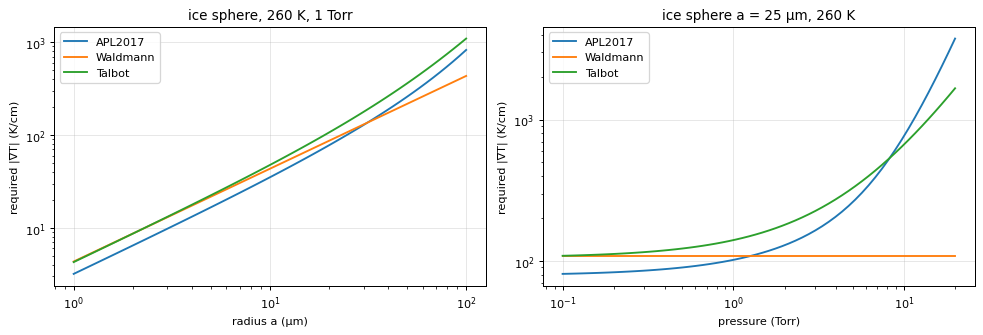

In [32]:
def required_gradient_K_per_cm(a, gas, model, density=917.0):
    return 4/3*np.pi*a**3*density*9.81/sphere_gamma(a, gas, model)*gas["T"]/100

a_s, p_s = np.logspace(-6, -4, 60), np.logspace(-1, 1.3, 60)
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
for model in ["APL2017", "Waldmann", "Talbot"]:
    axs[0].loglog(1e6*a_s, [required_gradient_K_per_cm(a, GAS_DEFAULT, model) for a in a_s], label=model)
    axs[1].loglog(p_s, [required_gradient_K_per_cm(25e-6, gas_properties(260.0, pp), model) for pp in p_s], label=model)
axs[0].set(xlabel="radius a (µm)", ylabel="required |∇T| (K/cm)", title="ice sphere, 260 K, 1 Torr"); axs[0].legend()
axs[1].set(xlabel="pressure (Torr)", ylabel="required |∇T| (K/cm)", title="ice sphere a = 25 µm, 260 K"); axs[1].legend()
fig.tight_layout(); plt.show()

### 10.7 Adding a new particle type

A builder is any function that returns a `Particle`. It must supply the mass, the inertia about the COM, `res` and `thermo` about the force centre, `rH`, and a `shape` for drawing. After you register it, every tool in this notebook works with it. Template:

In [33]:
def janus_sphere_particle(radius, lambda_a, **kw):
    """Uniform sphere with a user-supplied polar (Janus-type) alignment coefficient lambda_a (N m^2)."""
    p = sphere_particle(radius, **kw)
    return replace(p, name=f"Janus sphere {1e6*radius:.3g} µm", thermo=thermo_from_blocks(p.Gamma, lambda_a*skew([0, 0, 1])))

register_particle_type("JanusSphere", janus_sphere_particle, ["radius", "lambda_a", "density", "gas"],
                       "Sphere with an antisymmetric thermophoretic torque tensor; lambda_a must come from theory or measurement.")
list(PARTICLE_LIBRARY)

['Sphere', 'Ellipsoid', 'GradedEllipsoid', 'JanusSphere']

## 11. Physical particles in the trap (SI units)

### 11.1 Ice sphere, 25 µm radius

The trap curvature is set from the trap frequencies $f_r=2$ Hz and $f_z=3$ Hz. Drag relaxes the motion in about 27 ms, so the radial motion is overdamped and the axial mode is barely underdamped. The linearised eigenvalues match the analytic roots of $Ms^2+Ks+\Gamma\alpha=0$. Levitation needs about 102 K/cm.

In [34]:
env_sphere = make_environment(sphere25, alpha=alpha_from_trap_frequencies(sphere25, 2, 3))
traj_sphere = nd_simulate(sphere25, env_sphere, initial_state([100e-6, 50e-6, 80e-6], [0, 0, 0], [0, 0, 0]), 1.5)
J_sphere = linearize(sphere25, env_sphere, [0, 0, 0], [1, 0, 0, 0])
check_close("trap curvature (alpha_r, alpha_z)", np.diag(env_sphere.A)[[0, 2]], [630.44175, 1418.49393], 1e-6)
check_close("required |grad T| (K/cm)", required_temperature_gradient(env_sphere, 260)/100, 101.82809, 1e-6)
check_close("x(t = 0.1 s)", traj_sphere.sol(0.1)[0:3], [7.15559708e-5, 3.57779854e-5, 3.46621780e-5], 1e-6)
roots = np.roots([sphere25.mass, sphere25.res[0, 0], sphere25.thermo[2, 2]*env_sphere.A[2, 2]])
ev = sorted_eigs(J_sphere)
check_close("axial eigenvalue vs roots of M s^2 + K s + Gamma alpha_z", ev[ev.imag > 0.1][0], roots[roots.imag > 0][0], 1e-8)
mode_table(J_sphere, "25 µm ice sphere")
print(conduction_consistency(env_sphere))

PASS  trap curvature (alpha_r, alpha_z)
      got [ 630.4417483  1418.49393367]   expected [ 630.44175 1418.49393]   rel. err 2.60e-09
PASS  required |grad T| (K/cm)
      got 101.82808866   expected 101.82809   rel. err 1.31e-08
PASS  x(t = 0.1 s)
      got [7.15559708e-05 3.57779854e-05 3.46621780e-05]   expected [7.15559708e-05 3.57779854e-05 3.46621780e-05]   rel. err 4.41e-10
PASS  axial eigenvalue vs roots of M s^2 + K s + Gamma alpha_z
      got -18.58689395+3.13578246j   expected -18.58689395+3.13578246j   rel. err 1.24e-15


**25 µm ice sphere**

| eigenvalue (1/s) | decay rate (1/s) | frequency (Hz) | Q | type |
|---|---|---|---|---|
| 0 + 0 i | -0 | 0 | – | neutral |
| 0 + 0 i | -0 | 0 | – | neutral |
| 0 + 0 i | -0 | 0 | – | neutral |
| -4.89168 + 0 i | 4.892 | 0 | – | stable |
| -4.89168 + 0 i | 4.892 | 0 | – | stable |
| -18.5869 + 3.13578 i | 18.59 | 0.4991 | 0.507 | stable |
| -18.5869 − 3.13578 i | 18.59 | 0.4991 | 0.507 | stable |
| -32.2821 + 0 i | 32.28 | 0 | – | stable |
| -32.2821 + 0 i | 32.28 | 0 | – | stable |
| -38.6586 + 0 i | 38.66 | 0 | – | stable |
| -38.6586 + 0 i | 38.66 | 0 | – | stable |
| -38.6586 + 0 i | 38.66 | 0 | – | stable |

{'div G (model)': np.float64(2679.377430259593), 'div G required by source-free conduction': np.float64(-2760.965584708336)}


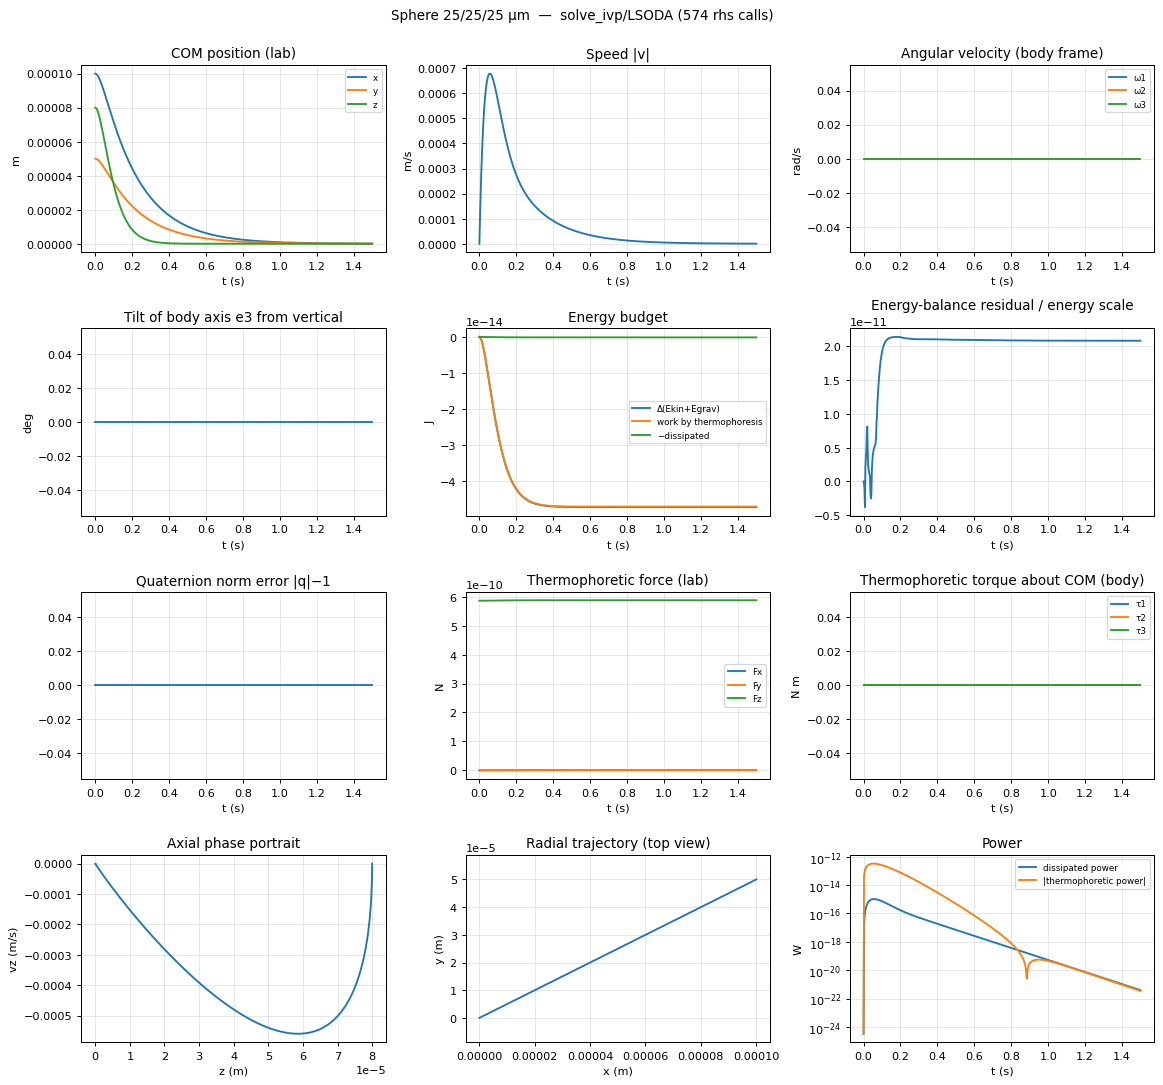

In [35]:
diagnostic_plots(traj_sphere)

### 11.2 Tilted prolate ellipsoid: sideways equilibrium

A uniform 15/15/30 µm ellipsoid has no restoring torque, so its orientation is neutral. Start it at 45° tilt at the trap centre. Because $K_{33}<K_{11}$, the thermophoretic force $-R\Gamma R^{\mathsf T}\mathbf G$ is not vertical. The particle drifts 4.5 mm sideways and 1.75 mm up to a new equilibrium, which `equilibrium_prediction` gives in closed form. A tilted anisotropic particle therefore never sits on the trap axis.

PASS  predicted equilibrium (m)
      got [0.         0.00451386 0.00175161]   expected [0.         0.00451386 0.00175161]   rel. err 7.09e-07
PASS  force residual at predicted equilibrium (m/s^2)
      got 1.12737332e-15   expected 0   abs. err 1.13e-15
PASS  simulated position at t = 3 s
      got [0.         0.00451316 0.00175161]   expected [0.         0.00451316 0.00175161]   rel. err 7.52e-07
PASS  tilt stays at 45 deg (neutral orientation)
      got 45.   expected 45.   rel. err 1.58e-16


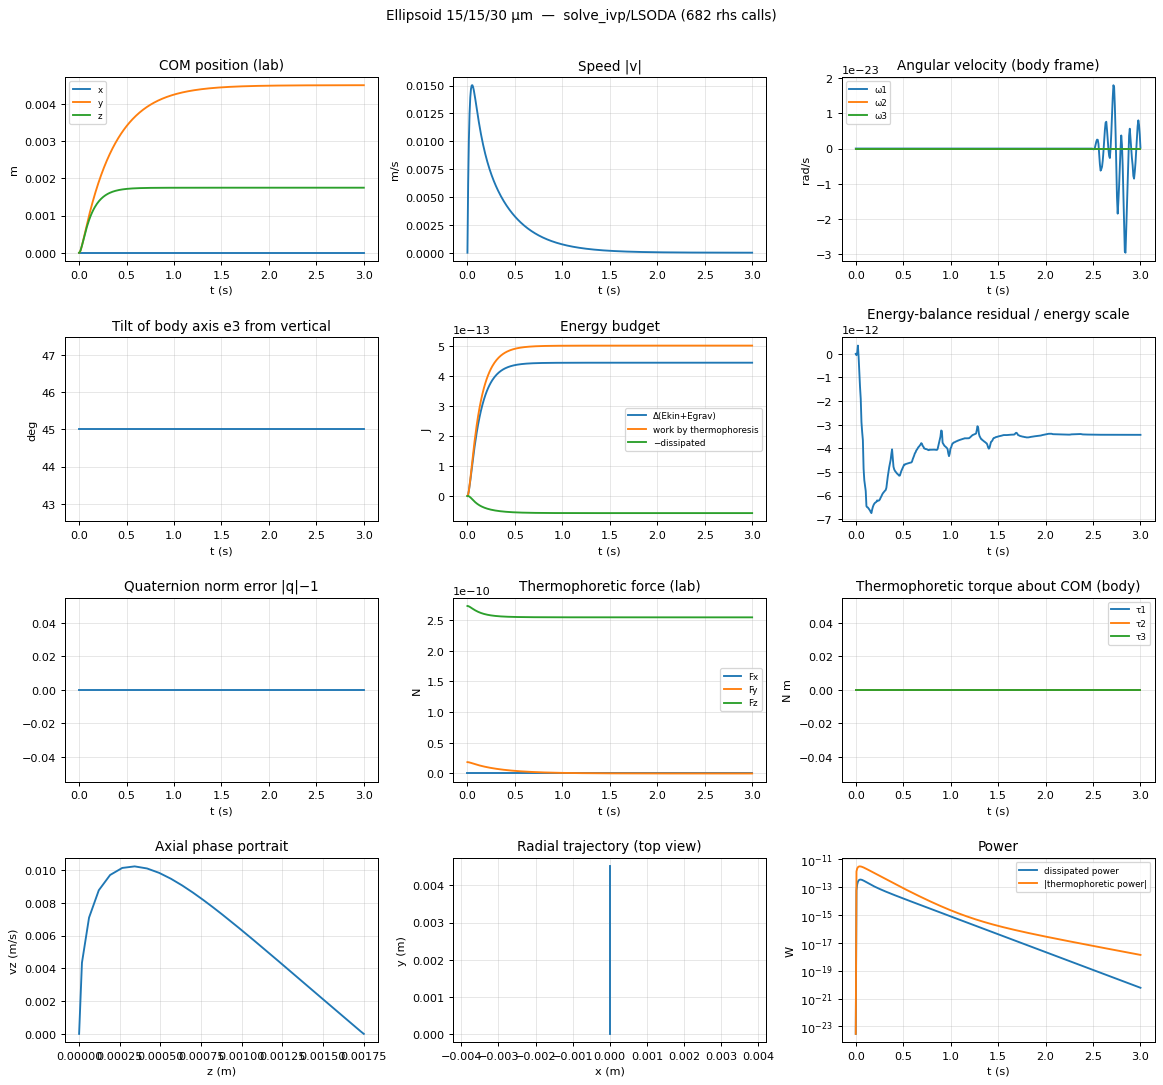

In [36]:
env_prolate = make_environment(prolate, alpha=alpha_from_trap_frequencies(prolate, 2, 3))
eq_prolate = equilibrium_prediction(prolate, env_prolate, axis_angle_q([1, 0, 0], 45))
traj_prolate = nd_simulate(prolate, env_prolate, initial_state([0, 0, 0], [0, 0, 0], [0, 0, 0], 45), 3.0, frames=401)
check_close("predicted equilibrium (m)", eq_prolate["xCOM"], [0, 0.00451386, 0.00175161], 1e-5)
check_abs("force residual at predicted equilibrium (m/s^2)", np.linalg.norm(eq_prolate["linear_acc_residual"]), 0, 1e-9)
check_close("simulated position at t = 3 s", traj_prolate.s[-1, 0:3], [0, 0.00451316, 0.00175161], 1e-4)
check_close("tilt stays at 45 deg (neutral orientation)", tilt_deg(traj_prolate.s[-1, 6:10]), 45.0, 1e-8)
diagnostic_plots(traj_prolate)

### 11.3 Bottom-heavy ellipsoid rights itself

Now take the same ellipsoid with $\varepsilon a_3=-0.6$, so the COM sits 3.6 µm below the force centre H. Release it at 30° tilt with H at the trap centre, and it swings back upright like a damped pendulum. Three predictions are compared:

* the naive estimate $\omega_p^2=Mg|z_c|/I_\perp$;
* the anisotropy-corrected estimate $\kappa=Mg|z_c|\Gamma_{11}/\Gamma_{33}$;
* the full 12×12 linearisation, which also includes the coupling to translation and the trap curvature at H.

In [37]:
env_graded = make_environment(graded, alpha=alpha_from_trap_frequencies(graded, 2, 3))
s_graded = initial_state(-graded.rH, [0, 0, 0], [0, 0, 0], 30)
traj_graded = nd_simulate(graded, env_graded, s_graded, 0.5, frames=1001)
J_graded = linearize(graded, env_graded, -graded.rH, [1, 0, 0, 0])
ev = sorted_eigs(J_graded); pend = ev[ev.imag > 100][0]
check_close("tilt(t = 0.05, 0.1 s)", [tilt_deg(traj_graded.sol(t)[6:10]) for t in (0.05, 0.1)], [5.4866305, 0.9520128], 1e-5)
check_close("pendulum eigenvalue (full linearisation)", pend, -31.831198 + 435.460221j, 1e-6)
check_close("anisotropy-corrected |omega_p| vs |eigenvalue|", np.sqrt(righting_stiffness(graded)/graded.inertia[0, 0]), abs(pend), 2e-3)
print(f"naive sqrt(Mg|zc|/I_perp) = {np.sqrt(graded.mass*9.81*abs(graded.meta['zc'])/graded.inertia[0, 0]):.1f} rad/s; "
      f"corrected = {np.sqrt(righting_stiffness(graded)/graded.inertia[0, 0]):.1f} rad/s; |eigenvalue| = {abs(pend):.1f} rad/s")
mode_table(J_graded, "Bottom-heavy ellipsoid")

PASS  tilt(t = 0.05, 0.1 s)
      got [5.48663051 0.95201287]   expected [5.4866305 0.9520128]   rel. err 1.28e-08
PASS  pendulum eigenvalue (full linearisation)
      got -31.83119772+435.46022127j   expected -31.831198+435.460221j   rel. err 9.06e-10
PASS  anisotropy-corrected |omega_p| vs |eigenvalue|
      got 436.75762242   expected 436.62206708   rel. err 3.10e-04
naive sqrt(Mg|zc|/I_perp) = 408.1 rad/s; corrected = 436.8 rad/s; |eigenvalue| = 436.6 rad/s


**Bottom-heavy ellipsoid**

| eigenvalue (1/s) | decay rate (1/s) | frequency (Hz) | Q | type |
|---|---|---|---|---|
| 0 + 0 i | -0 | 0 | – | neutral |
| -2.95615 + 2.30756e-15 i | 2.956 | 3.673e-16 | 0.5 | stable |
| -2.95615 − 2.30756e-15 i | 2.956 | 3.673e-16 | 0.5 | stable |
| -8.68445 + 0 i | 8.684 | 0 | – | stable |
| -31.8312 + 435.46 i | 31.83 | 69.31 | 6.86 | stable |
| -31.8312 − 435.46 i | 31.83 | 69.31 | 6.86 | stable |
| -31.8312 + 435.46 i | 31.83 | 69.31 | 6.86 | stable |
| -31.8312 − 435.46 i | 31.83 | 69.31 | 6.86 | stable |
| -40.9129 + 0 i | 40.91 | 0 | – | stable |
| -46.6698 + 0 i | 46.67 | 0 | – | stable |
| -46.6698 + 0 i | 46.67 | 0 | – | stable |
| -66.9468 + 0 i | 66.95 | 0 | – | stable |

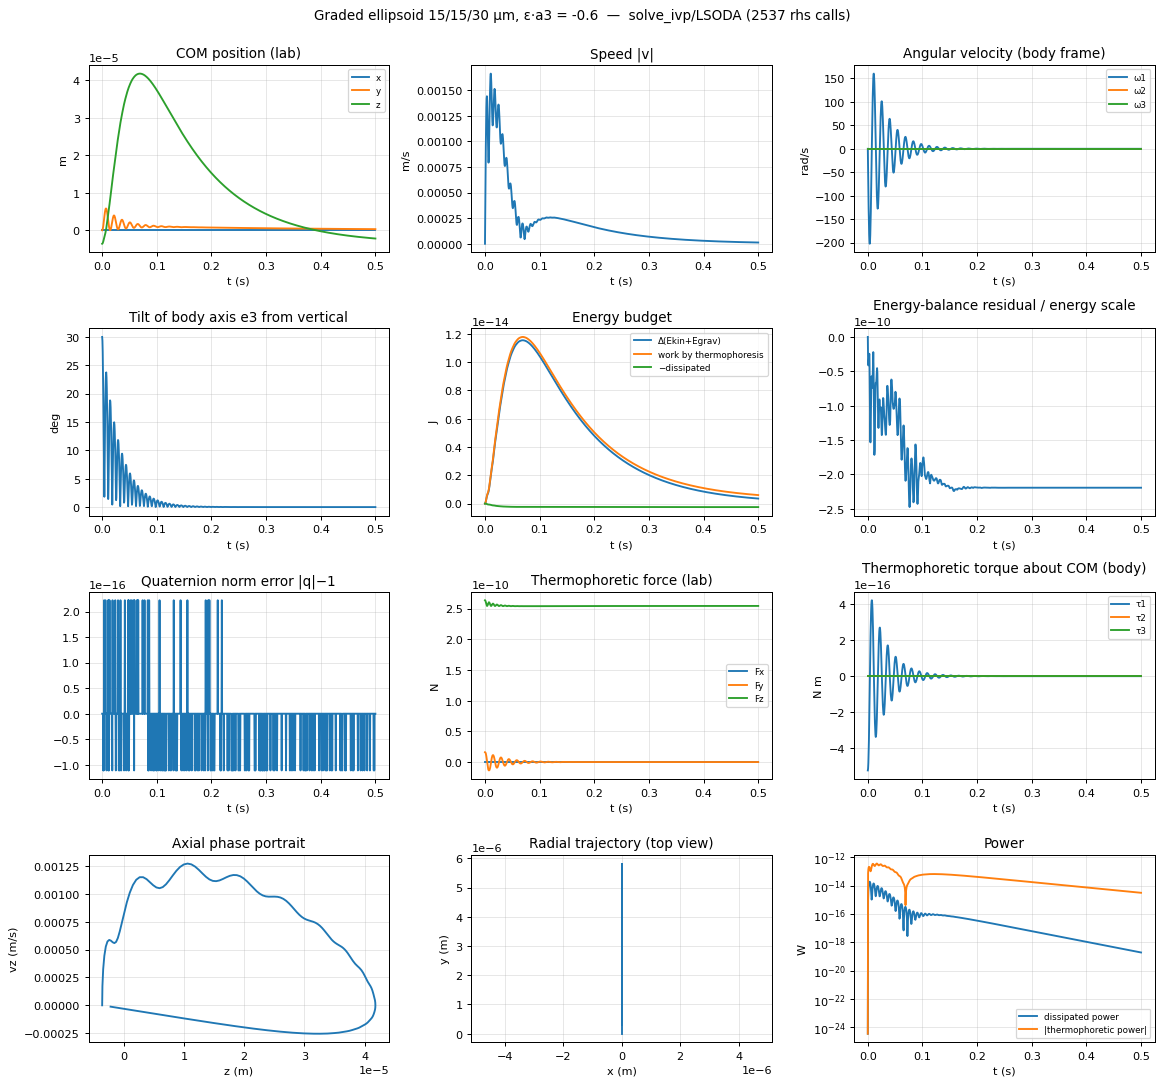

In [38]:
diagnostic_plots(traj_graded)

In [39]:
show_animation(traj_graded, elev=12, azim=60)

**Integrator cross-check.** RK4 at $\Delta t=10^{-4}$ s is well inside its stability region, and it must agree with the adaptive solver. The commented line writes a GIF.

In [40]:
print(rk4_stability(J_graded, 1e-4))
tr = rk4_simulate(graded, env_graded, s_graded, 0.1, 1000)
check_close("RK4 vs adaptive tilt at t = 0.1 s", tilt_deg(tr.s[-1, 6:10]), tilt_deg(traj_graded.sol(0.1)[6:10]), 1e-5)
# save_animation(traj_graded, FIG_DIR / "graded_ellipsoid.gif")

{'dt': 0.0001, 'max|λ|dt': np.float64(0.04366220670792893), 'max RK4 amplification': np.float64(1.0), 'verdict': 'stable'}
PASS  RK4 vs adaptive tilt at t = 0.1 s
      got 0.95201223   expected 0.95201287   rel. err 6.72e-07


## 12. Control parameters

### 12.1 Parameter maps from the linearisation

The linearisation is cheap, so it can map how the design parameters control each particle. The maps below show:

* **left:** the righting (pendulum) frequency and quality factor of the graded ellipsoid versus $\varepsilon a_3$, at several pressures;
* **middle:** the same versus aspect ratio $a_3/a_1$, at fixed volume;
* **right:** the sideways equilibrium offset of a uniform ellipsoid versus tilt angle, for several aspect ratios.

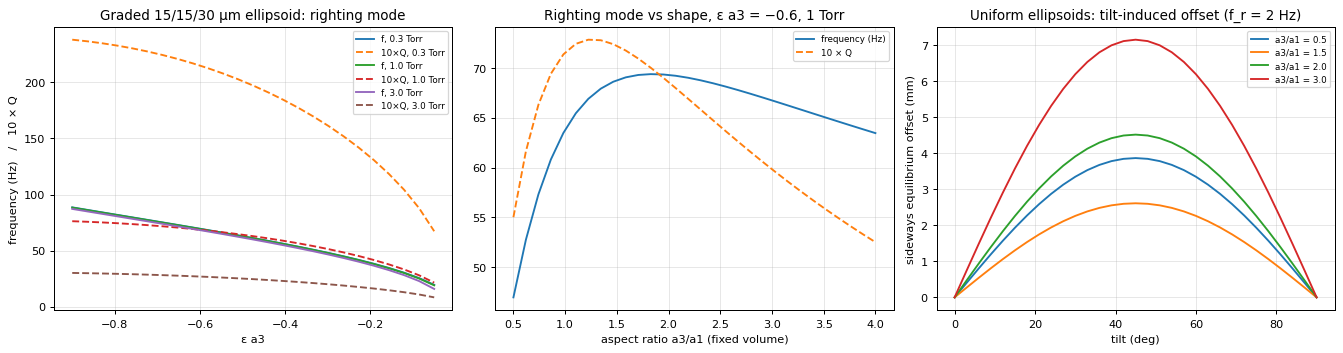

In [41]:
def pendulum_mode(p, fr=2, fz=3):
    env = make_environment(p, alpha=alpha_from_trap_frequencies(p, fr, fz))
    ev = sorted_eigs(linearize(p, env, -p.rH, [1, 0, 0, 0]))
    rot = ev[(np.abs(ev) > 0)]
    osc = rot[rot.imag > 0]
    lam = osc[np.argmax(np.abs(osc))] if len(osc) else rot[np.argmin(np.abs(rot.real))]
    return abs(lam.imag)/(2*np.pi), (abs(lam)/(-2*lam.real) if lam.imag != 0 else 0.5)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
eps_s = np.linspace(-0.9, -0.05, 25)
for pt in [0.3, 1.0, 3.0]:
    gas = gas_properties(260.0, pt)
    fq = np.array([pendulum_mode(graded_ellipsoid_particle([15e-6, 15e-6, 30e-6], epsilon_a3=e, gas=gas)) for e in eps_s])
    axs[0].plot(eps_s, fq[:, 0], label=f"f, {pt} Torr"); axs[0].plot(eps_s, fq[:, 1]*10, "--", label=f"10×Q, {pt} Torr")
axs[0].set(xlabel="ε a3", ylabel="frequency (Hz)   /   10 × Q", title="Graded 15/15/30 µm ellipsoid: righting mode"); axs[0].legend(fontsize=7)
asp = np.linspace(0.5, 4, 30); V = 15e-6**2*30e-6
fq = np.array([pendulum_mode(graded_ellipsoid_particle([(V/r)**(1/3)]*2 + [r*(V/r)**(1/3)], epsilon_a3=-0.6)) for r in asp])
axs[1].plot(asp, fq[:, 0], label="frequency (Hz)"); axs[1].plot(asp, 10*fq[:, 1], "--", label="10 × Q")
axs[1].set(xlabel="aspect ratio a3/a1 (fixed volume)", title="Righting mode vs shape, ε a3 = −0.6, 1 Torr"); axs[1].legend(fontsize=7)
tilts_s = np.linspace(0, 90, 31)
for r in [0.5, 1.5, 2.0, 3.0]:
    a = (V/r)**(1/3); pr = ellipsoid_particle([a, a, r*a])
    envp = make_environment(pr, alpha=alpha_from_trap_frequencies(pr, 2, 3))
    off = [1e3*np.linalg.norm(equilibrium_prediction(pr, envp, axis_angle_q([1, 0, 0], tt))["xCOM"][:2]) for tt in tilts_s]
    axs[2].plot(tilts_s, off, label=f"a3/a1 = {r}")
axs[2].set(xlabel="tilt (deg)", ylabel="sideways equilibrium offset (mm)", title="Uniform ellipsoids: tilt-induced offset (f_r = 2 Hz)"); axs[2].legend(fontsize=7)
fig.tight_layout(); plt.show()

### 12.2 Interactive explorer

The explorer simulates a graded ellipsoid in air at 260 K. You can set the pressure, size, aspect ratio, density gradient, initial tilt and trap frequencies. Each change re-runs the adaptive integration and shows the tilt, the height and the particle's cross-section. It needs `ipywidgets` and a live kernel.

In [42]:
def explore(p_torr=1.0, a1_um=15.0, aspect=2.0, eps_a3=-0.6, tilt0=30.0, fr=2.0, fz=3.0, t_end=0.5):
    p = graded_ellipsoid_particle(np.array([a1_um, a1_um, aspect*a1_um])*1e-6, epsilon_a3=eps_a3, gas=gas_properties(260.0, p_torr))
    env = make_environment(p, alpha=alpha_from_trap_frequencies(p, fr, fz))
    d = trajectory_diagnostics(nd_simulate(p, env, initial_state(-p.rH, [0, 0, 0], [0, 0, 0], tilt0), t_end, frames=401))
    fig, axs = plt.subplots(1, 3, figsize=(13, 3.6))
    axs[0].plot(d["t"], d["tilt"]); axs[0].set(xlabel="t (s)", ylabel="tilt (deg)", title="tilt")
    axs[1].plot(d["t"], 1e6*d["x"][:, 2]); axs[1].set(xlabel="t (s)", ylabel="z (µm)", title="COM height")
    particle_diagram(p, axs[2], tilt=tilt0); fig.tight_layout(); plt.show()
    print(f"required |∇T| = {required_temperature_gradient(env, 260)/100:.4g} K/cm,  Kn = {p.meta['Kn']:.3g},  "
          f"righting stiffness = {righting_stiffness(p):.3g} N m")

try:
    import ipywidgets as W
    W.interact_manual(explore, p_torr=(0.1, 10.0, 0.1), a1_um=(3.0, 60.0, 1.0), aspect=(0.3, 4.0, 0.1),
                      eps_a3=(-0.95, 0.95, 0.05), tilt0=(0.0, 170.0, 5.0), fr=(0.2, 10.0, 0.2), fz=(0.2, 10.0, 0.2),
                      t_end=(0.05, 5.0, 0.05))
except ImportError:
    print("ipywidgets not installed; calling explore() with defaults instead.")
    explore()

[interactive widget: re-run this cell in a live Jupyter kernel with ipywidgets installed]


## 13. Test summary, limitations and next steps

In [43]:
n_pass = sum(TEST_RESULTS.values())
print(f"Tests passed: {n_pass} / {len(TEST_RESULTS)}")
for k, ok in TEST_RESULTS.items():
    if not ok: print("  FAILED:", k)

Tests passed: 43 / 43


* **Linear response only.** The tensors are constant in the body frame and are evaluated at a single reference temperature and pressure. Coefficients do not follow the local gas state. Forces from higher derivatives of $T$ across the particle are omitted.
* **Rarefied non-spherical drag.** The ellipsoid shape tensors come from continuum (Oberbeck/Jeffery) theory with sphere-equivalent slip corrections. The natural next library addition is a free-molecular module that builds $\mathcal R$ and $\mathcal T$ from surface integrals of $\hat{\mathbf n}\hat{\mathbf n}$ and $\hat{\mathbf n}$.
* **Isotropic thermophoretic velocity** for ellipsoids is exact only in the continuum limit for an insulating particle. Replace $\mathcal T$ when measurements or kinetic-theory results are available.
* **The harmonic trap is phenomenological** (see the note in Section 4.3). A `custom_field` can instead supply a gradient interpolated from the output of `Temperature_Gradient.py`.
* **Buoyancy** in the gas and **radiometric (photophoretic) forces** are neglected.